## Top hBN slitghly thinner than bottom 
## Back gate wider than top gate 
## 250 nm cut EBL --> Real one probably 150 nm

## Import the modules you need (this does not need to change)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import glob
import os
import matplotlib.cm as cm
import math as math
from scipy import signal
from scipy.fftpack import fft, ifft
from scipy.signal import savgol_filter
from collections import Counter
from ipywidgets import interactive
#import ipympl
from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA
import matplotlib.ticker as mticker

from scipy.integrate import simps
from numpy import trapz
import matplotlib.ticker as ticker

import matplotlib 
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import time

class Object():
    pass

import _pickle as pickle

In [3]:
 plt.rcParams["font.family"] = "arial"

## All the functions for plotting are in here

In [4]:
import LDQM_dataplot

importlib.reload(LDQM_dataplot)


<module 'LDQM_dataplot' from 'C:\\jdiez_local\\Code\\LDQM_dataplot.py'>

In [5]:
savename='C:/Users/jdiez/LDQM/a. Data/Ju1/Fig/'
savecount=1

In [6]:
cm_data = [[0.2081, 0.1663, 0.5292], [0.2116238095, 0.1897809524, 0.5776761905], 
 [0.212252381, 0.2137714286, 0.6269714286], [0.2081, 0.2386, 0.6770857143], 
 [0.1959047619, 0.2644571429, 0.7279], [0.1707285714, 0.2919380952, 
  0.779247619], [0.1252714286, 0.3242428571, 0.8302714286], 
 [0.0591333333, 0.3598333333, 0.8683333333], [0.0116952381, 0.3875095238, 
  0.8819571429], [0.0059571429, 0.4086142857, 0.8828428571], 
 [0.0165142857, 0.4266, 0.8786333333], [0.032852381, 0.4430428571, 
  0.8719571429], [0.0498142857, 0.4585714286, 0.8640571429], 
 [0.0629333333, 0.4736904762, 0.8554380952], [0.0722666667, 0.4886666667, 
  0.8467], [0.0779428571, 0.5039857143, 0.8383714286], 
 [0.079347619, 0.5200238095, 0.8311809524], [0.0749428571, 0.5375428571, 
  0.8262714286], [0.0640571429, 0.5569857143, 0.8239571429], 
 [0.0487714286, 0.5772238095, 0.8228285714], [0.0343428571, 0.5965809524, 
  0.819852381], [0.0265, 0.6137, 0.8135], [0.0238904762, 0.6286619048, 
  0.8037619048], [0.0230904762, 0.6417857143, 0.7912666667], 
 [0.0227714286, 0.6534857143, 0.7767571429], [0.0266619048, 0.6641952381, 
  0.7607190476], [0.0383714286, 0.6742714286, 0.743552381], 
 [0.0589714286, 0.6837571429, 0.7253857143], 
 [0.0843, 0.6928333333, 0.7061666667], [0.1132952381, 0.7015, 0.6858571429], 
 [0.1452714286, 0.7097571429, 0.6646285714], [0.1801333333, 0.7176571429, 
  0.6424333333], [0.2178285714, 0.7250428571, 0.6192619048], 
 [0.2586428571, 0.7317142857, 0.5954285714], [0.3021714286, 0.7376047619, 
  0.5711857143], [0.3481666667, 0.7424333333, 0.5472666667], 
 [0.3952571429, 0.7459, 0.5244428571], [0.4420095238, 0.7480809524, 
  0.5033142857], [0.4871238095, 0.7490619048, 0.4839761905], 
 [0.5300285714, 0.7491142857, 0.4661142857], [0.5708571429, 0.7485190476, 
  0.4493904762], [0.609852381, 0.7473142857, 0.4336857143], 
 [0.6473, 0.7456, 0.4188], [0.6834190476, 0.7434761905, 0.4044333333], 
 [0.7184095238, 0.7411333333, 0.3904761905], 
 [0.7524857143, 0.7384, 0.3768142857], [0.7858428571, 0.7355666667, 
  0.3632714286], [0.8185047619, 0.7327333333, 0.3497904762], 
 [0.8506571429, 0.7299, 0.3360285714], [0.8824333333, 0.7274333333, 0.3217], 
 [0.9139333333, 0.7257857143, 0.3062761905], [0.9449571429, 0.7261142857, 
  0.2886428571], [0.9738952381, 0.7313952381, 0.266647619], 
 [0.9937714286, 0.7454571429, 0.240347619], [0.9990428571, 0.7653142857, 
  0.2164142857], [0.9955333333, 0.7860571429, 0.196652381], 
 [0.988, 0.8066, 0.1793666667], [0.9788571429, 0.8271428571, 0.1633142857], 
 [0.9697, 0.8481380952, 0.147452381], [0.9625857143, 0.8705142857, 0.1309], 
 [0.9588714286, 0.8949, 0.1132428571], [0.9598238095, 0.9218333333, 
  0.0948380952], [0.9661, 0.9514428571, 0.0755333333], 
 [0.9763, 0.9831, 0.0538]]

parula_map = LinearSegmentedColormap.from_list('parula', cm_data)

In [7]:
%matplotlib inline
import LDQM_dataplot
import homemade_functions 
import MATBG_Temp_Dependance

from homemade_functions import runningMeanFast
from homemade_functions import plot_pre,plot_map,plot_line,plot_premap,saving_figure
from MATBG_Temp_Dependance import Arrhenius, CI_Gap,SC_gap, plot_temp, plot_RT

savename='C:/jdiez_local/LDQM/a. Data/2023 April/'
savecount=1

orig_cmap = matplotlib.cm.RdBu_r
mycolor=LDQM_dataplot.shiftedColorMap(0.4,orig_cmap)

font=16

def update_modules():
    
    importlib.reload(LDQM_dataplot)
    importlib.reload(homemade_functions)
    importlib.reload(MATBG_Temp_Dependance)
class Object():
    pass

## May 2021

# Low B 

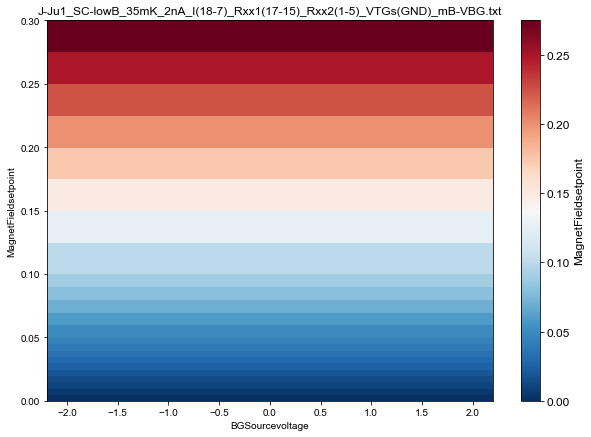

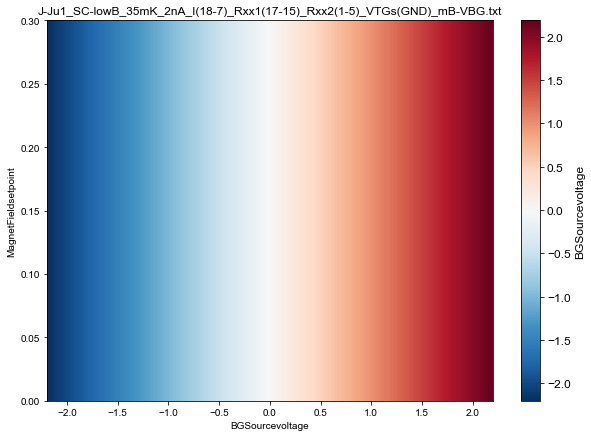

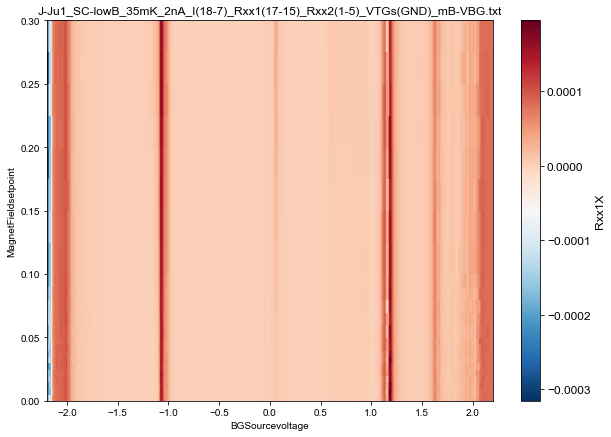

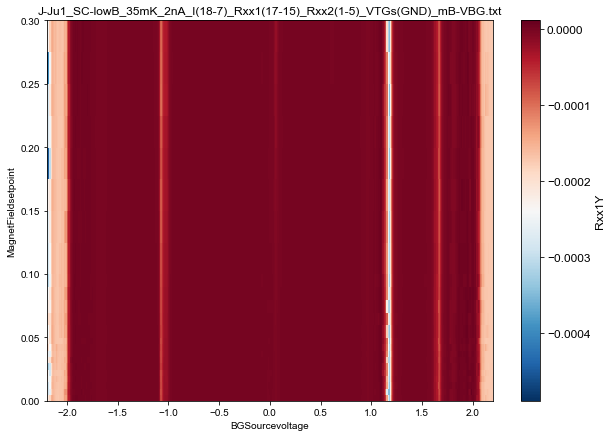

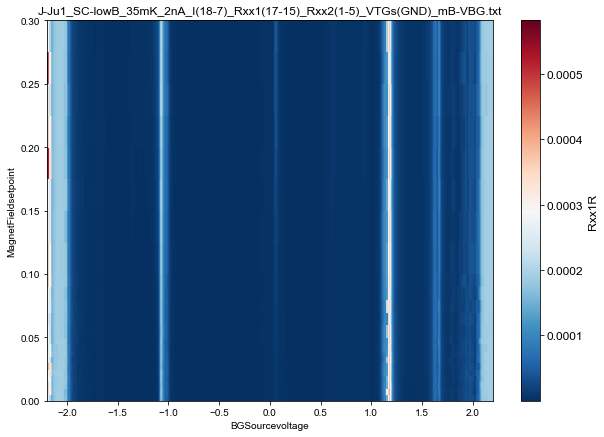

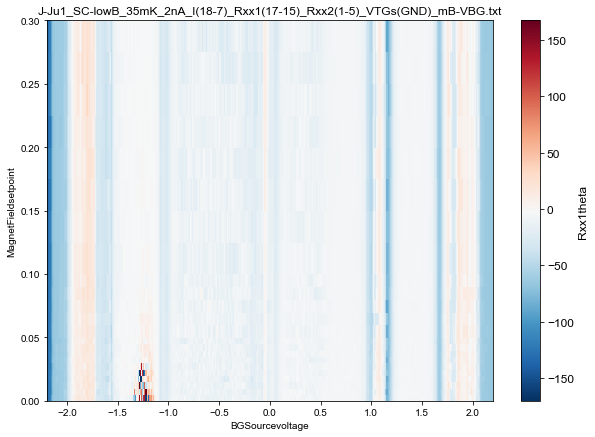

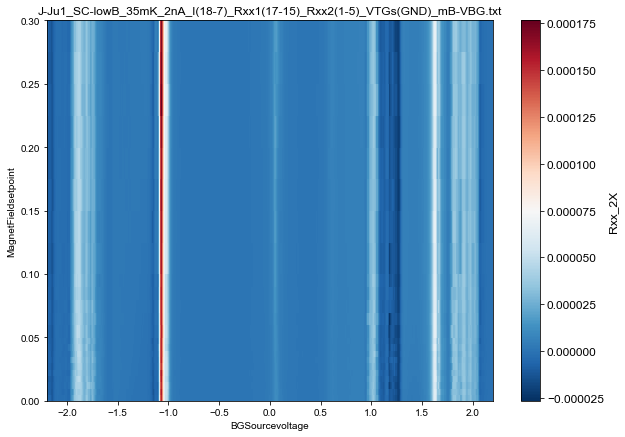

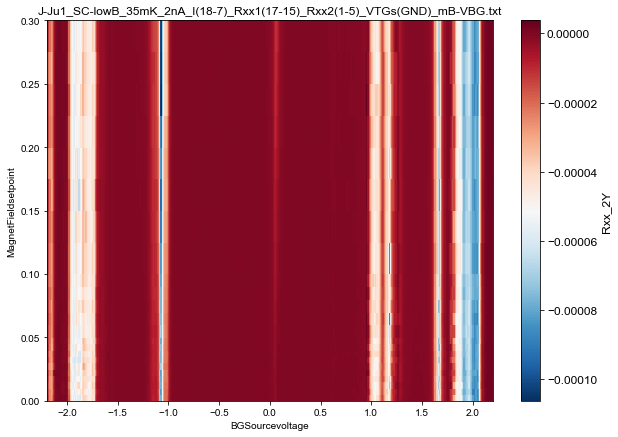

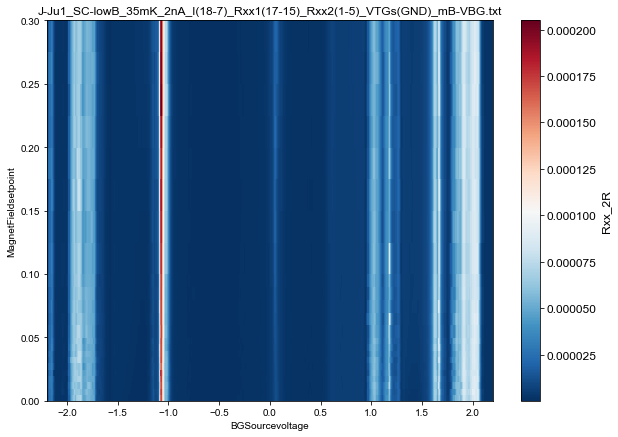

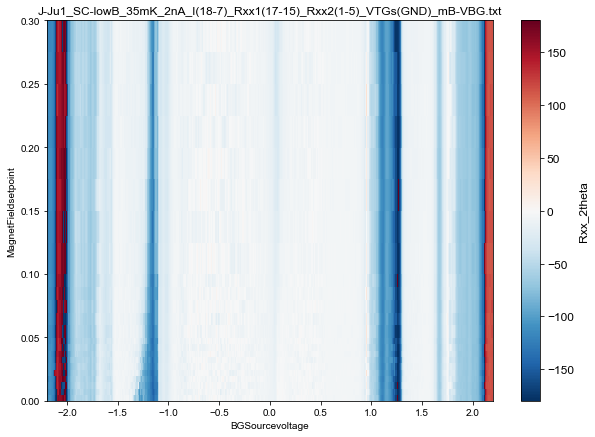

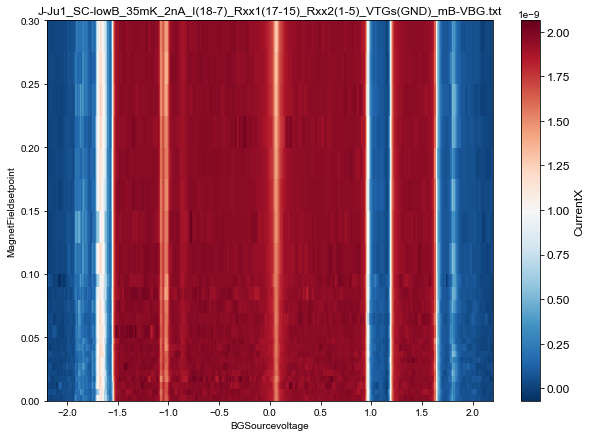

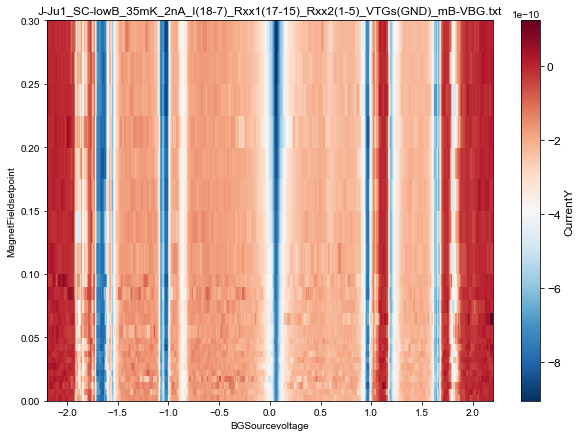

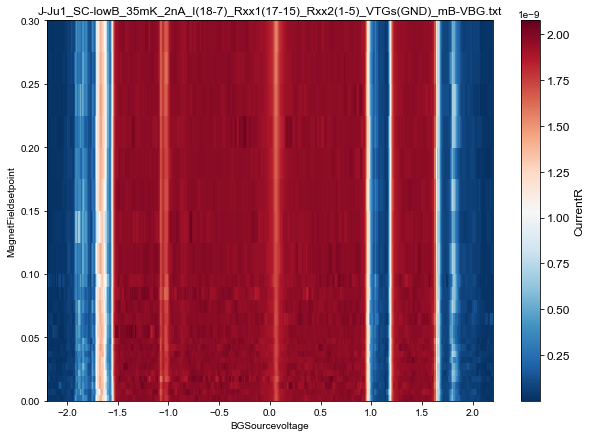

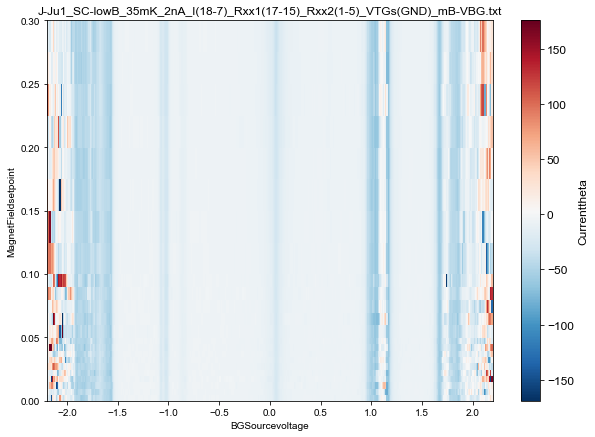

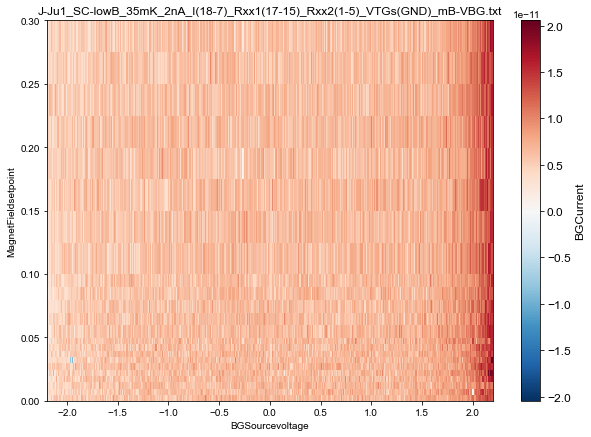

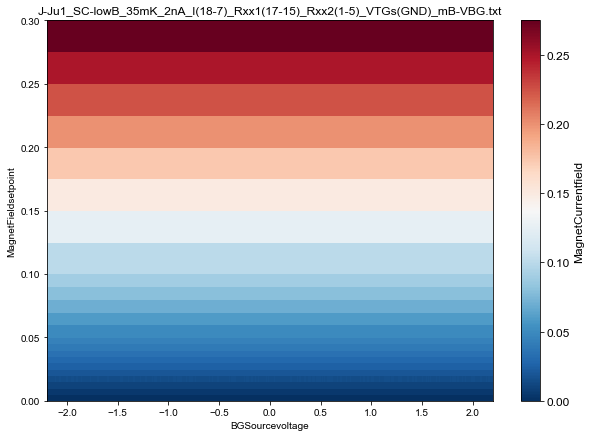

In [7]:
Bc1_directory = 'C:/Users/jdiez/LDQM/a. Data/2021 May'
Bc1_folder='/Ju1/SC_characterization/'
Bc1_directory= Bc1_directory+Bc1_folder

Bc1_files=[
    'J-Ju1_SC-lowB_35mK_2nA_I(18-7)_Rxx1(17-15)_Rxx2(1-5)_VTGs(GND)_mB-VBG.txt',
 ]

Bc1_obj = {} #stores all the data
Bc1_raw ={} #store the xaxis data for plotting
Bc1_variables={} #store the data to plot in the right units

# All IV curves
# scan type = 0

for i in range(len(Bc1_files)):
    file=Bc1_directory+Bc1_files[i]
    Bc1_obj['data'+str(i)], Bc1_variables['data'+str(i)],Bc1_raw['data'+str(i)]=LDQM_dataplot.plot_map_fromfiles(file)


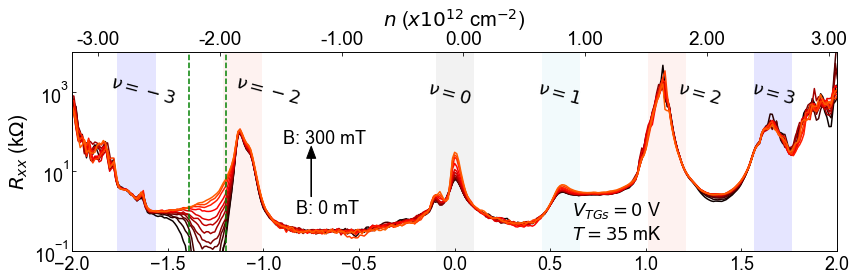

In [12]:
# Fig params to save and color 
font = 18

ns=2.88

cap=1.83E-3/1.602E-19/0.88
Vns=ns/cap*1E16  

if savecount==0:
    save=True
else:
    save=False

num_plot=(len(Bc1_Rxx1)+1)
nipyspbig = plt.get_cmap('hot', 512)
newcmp = ListedColormap(nipyspbig(np.linspace(0, 0.5, 256)))    
cmap = plt.get_cmap(newcmp)
    
colors = [cmap(i) for i in np.linspace(0, 1, int(num_plot/2))]

fig=plt.figure(figsize=(12,4))

count=0
ax = plt.subplot(111)

for i in range(1,num_plot-1,2):  
    #plt.plot((Bc1_BG[i]-0.055)*cap/1E16,Bc1_Rxx1[i],label='$B$'+'={0:.2f}'.format(Bc1_B[i,0]),color=colors[count])
    ax.plot((Bc1_BG[i]-0.055),Bc1_Rxx1[i],label='$B$'+'={0:.2f}'.format(Bc1_B[i,0]),color=colors[count])
    count=count+1
    
#plt.legend(fontsize=12)   
#ax.title('$R\ vs\ B$, $I:18-7$ (2 nA), $R_{xx}$:17-15',fontsize=font)
#ax.set_xlabel('$V_{BG}$ (V))',fontsize=font+2)
ax.set_ylabel('$R_{xx}$ (k$\Omega$)',fontsize=font+2)

ax.tick_params(axis='both', which='both', labelsize=font,direction='in')
#ax.tick_params(axis='x',which='both', bottom=False,top=False,labelbottom=False)

ax2 = ax.twiny()
ax2.set_xlabel('$n$ ($x10^{12}$ cm$^{-2}$)',fontsize=font+2)
ax2.set_xlim(ax.get_xlim())
ax2.tick_params(axis='both', which='major', labelsize=font+1,direction='in')
#ax2.set_xticks([-2,-1,0,1,2])
# apply a function formatter. Should be the back gate, so it should be the opposite of what i did on top
#((VBg_JJ2-CNP-1.25/25-VBg/25))
#formatter = mticker.FuncFormatter(lambda y_top, pos: '{:.2f}'.format(((y_top+CNP+(1.25+CNP)/0.88/25))/cap*1E16))
formatter = mticker.FuncFormatter(lambda y_top, pos: '{:.2f}'.format(y_top*cap/1E16))
ax2.xaxis.set_major_formatter(formatter)

ax2.set_xticks(np.array([-3,-2,-1,0,1,2,3])/cap*1E16)

#plt.annotate('$B$ (mT)',(-0.5,7),arrowprops=dict(facecolor='black', shrink=0.5),
#            horizontalalignment='right', verticalalignment='top',)
ax.annotate('B: 0 mT', xy=(-0.5, 2),
            xytext=(-0.5, 2),
            arrowprops=dict(facecolor='black',width=0.5,headwidth=9, shrink=0.05),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )
ax.annotate('', xy=(-0.75, 50),
            xytext=(-0.75, 2),
            arrowprops=dict(facecolor='black',width=0.5,headwidth=9, shrink=0.05),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )
ax.annotate('B: 300 mT', xy=(-0.9, 50),
            xytext=(-0.9,50),fontsize=font
            )

#plt.axvline(x=-0.67,color='grey',linestyle='dashed',linewidth=0.5)


# Make lines and vertical colors and fillings


ax.axvline(x=-1.55/cap*1E16,color='g',linestyle='dashed')
ax.axvline(x=-1.8/cap*1E16,color='g',linestyle='dashed')

nu_y=500

#ax.text(2.7/cap*1E16,nu_y,r'$\nu=4$',fontsize=font,rotation=-15)
ax.text(+2/cap*1E16,nu_y,r'$\nu=3$',fontsize=font,rotation=-15)
ax.text(+1.5/cap*1E16,nu_y,r'$\nu=2$',fontsize=font,rotation=-15)
ax.text(+0.55/cap*1E16,nu_y,r'$\nu=1$',fontsize=font,rotation=-15)
ax.text(-0.2/cap*1E16,nu_y,r'$\nu=0$',fontsize=font,rotation=-15)
ax.text(-1.5/cap*1E16,nu_y,r'$\nu=-2$',fontsize=font,rotation=-15)
ax.text(-2.35/cap*1E16,nu_y,r'$\nu=-3$',fontsize=font,rotation=-15)
#ax.text(-3/cap*1E16,nu_y,r'$\nu=-4$',fontsize=font,rotation=-15)


ax.text(0.8/cap*1E16,0.2,'$T=35$ mK',fontsize=font)
ax.text(0.8/cap*1E16,0.8,'$V_{TGs}=0$ V',fontsize=font)

ax.axvspan(-(Vns/2)+0.1, -(Vns/2)-0.1, facecolor='salmon',alpha=0.1)
ax.axvspan(-(Vns/4*3)+0.1, -(Vns/4*3)-0.1, facecolor='b',alpha=0.1)
#ax.axvspan(-(ns/2)+0.1, -(ns/2)-0.1, facecolor='b',alpha=0.1)
ax.axvspan((Vns/2)-0.1, (Vns/2)+0.1, facecolor='salmon',alpha=0.1)
ax.axvspan((Vns/4)-0.1, (Vns/4)+0.1, facecolor='skyblue',alpha=0.1)
ax.axvspan((Vns/4*3)-0.10, (Vns/4*3)+0.10, facecolor='b',alpha=0.1)
ax.axvspan(-0.1, 0.1, facecolor='silver',alpha=0.2)
ax.axvspan((Vns)-0.10, (Vns)+0.10, facecolor='firebrick',alpha=0.1)
ax.axvspan((-Vns)-0.10, (-Vns)+0.10, facecolor='firebrick',alpha=0.1)

ax.set_yscale('log')

ax.set_ylim(0.1,10000)
ax.set_xlim(-2,2)

plt.tight_layout()

if save:
    plt.savefig(savename+'RVgvsB_Vbgandn'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1

plt.show()

# JJ map

In [9]:
importlib.reload(LDQM_dataplot)

JJ_directory = 'C:/jdiez_local/LDQM/a. Data/2021 May'
JJ_folder='/Ju1/06_JJ_map/'
JJ_directory= JJ_directory+JJ_folder

JJ_files=['J-Ju1_JJ-line_35mK_5nA_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_m-Vbg_Idc.txt',
        'J-Ju1_JJ-line_35mK_2nA_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_m-Vbg_Idc2.txt',
        'J-Ju1_JJ-line_35mK_2nA_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Vtgs(-VBG-1p25div0p88V)_m-Vgates-Idc.txt',
         'J-Ju1_JJ-line_35mK_2nA_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Vtgs(-VBG-1p25div0p88V)_m-Vgates-Idc_cont.txt',
       'J-Ju1_JJ-line_35mK_2nA_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Vtgs(-VBG-1p2div0p88V)_m-Vgates-Idc_cont.txt',
          'J-Ju1_JJ_line_35mK_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Vtgs(-1p25-xdiv0p88mV)_mVbg-Idc.txt',
          'J-Ju1_JJline_CNP_35mK_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Vtgs(Vbg-1p25div0p88V)_m-Vbg_Idc.txt',
          'J-Ju1_JJ_line_35mK_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Vtgs(-1p25-xdiv0p88mV)_mVbg-Idc-up_2.txt'

]


JJ_obj = {} #stores all the data
JJ_variables={} #store the data to plot in the right units
JJ_name={}


for i in range(len(JJ_files)):
    file=JJ_directory+JJ_files[i]
    JJ_obj['data'+str(i)], JJ_variables['data'+str(i)],JJ_name['data'+str(i)]=LDQM_dataplot.plot_map_fromfiles(file)


In [10]:
#Put the -1.25 V together 
# Put them together

len1=len(JJ_obj['data2'].DCsource1V100nASourcevoltage)

len2=len(JJ_obj['data3'].DCsource1V100nASourcevoltage)
len3=len(JJ_obj['data5'].DCSource1V100nASourcevoltage)
len2=0
len4=len(JJ_obj['data7'].DCSource1V100nASourcevoltage)
tot_len=len1+len2+len3-6+len4

leny=len(JJ_obj['data2'].DCsource1V100nASourcevoltage[0])

DC_JJ2=np.zeros((tot_len,leny))
Rxx1517_JJ2=np.zeros((tot_len,leny))
Rxx51_JJ2=np.zeros((tot_len,leny))
VBg_JJ2=np.zeros((tot_len,leny))
I_JJ=np.zeros((tot_len,leny))

num=2
count=0
count2=0




num=5 
# Find the interpolation data of the 3rd scan
count2=0
for i in range(0,len3):
    if count2<len(JJ_obj['data'+str(7)].BGSourcevoltage):
        if JJ_obj['data'+str(num)].BGSourcevoltage[-1-i,0]<JJ_obj['data'+str(7)].BGSourcevoltage[-1-count2,0] and JJ_obj['data'+str(7)].BGSourcevoltage[-1-count2,0] <JJ_obj['data'+str(num)].BGSourcevoltage[-1-i-1,0]:
            DC_JJ2[count]=JJ_obj['data'+str(num)].DCSource1V100nASourcevoltage[-1-i]*100
            Rxx1517_JJ2[count]=JJ_obj['data'+str(num)].Rxx1_Ampx10X[-1-i]/JJ_obj['data'+str(num)].Rxx4X[-1-i]/10/1000
            Rxx51_JJ2[count]=JJ_obj['data'+str(num)].Rxx2_Ampx10X[-1-i]/JJ_obj['data'+str(num)].Rxx4X[-1-i]/10/1000
            VBg_JJ2[count]=JJ_obj['data'+str(num)].BGSourcevoltage[-1-i]
            I_JJ[count]=JJ_obj['data'+str(num)].Rxx4X[-1-i]
            #F1_I[i]=Bc1_obj['data0'].CurrentR[i]
            count=count+1  
            print(count)
            
            DC_JJ2[count]=JJ_obj['data'+str(7)].DCSource1V100nASourcevoltage[-1-count2]*100
            Rxx1517_JJ2[count]=JJ_obj['data'+str(7)].Rxx1_Ampx10X[-1-count2]/JJ_obj['data'+str(7)].Rxx4X[-1-count2]/10/1000
            Rxx51_JJ2[count]=JJ_obj['data'+str(7)].Rxx2_Ampx10X[-1-count2]/JJ_obj['data'+str(7)].Rxx4X[-1-count2]/10/1000
            VBg_JJ2[count]=JJ_obj['data'+str(7)].BGSourcevoltage[-1-count2]
            I_JJ[count]=JJ_obj['data'+str(7)].Rxx4X[-1-count2]
            count2=count2+1
            count=count+1 
            #print(i)
        else:
            DC_JJ2[count]=JJ_obj['data'+str(num)].DCSource1V100nASourcevoltage[-1-i]*100
            Rxx1517_JJ2[count]=JJ_obj['data'+str(num)].Rxx1_Ampx10X[-1-i]/JJ_obj['data'+str(num)].Rxx4X[-1-i]/10/1000
            Rxx51_JJ2[count]=JJ_obj['data'+str(num)].Rxx2_Ampx10X[-1-i]/JJ_obj['data'+str(num)].Rxx4X[-1-i]/10/1000
            VBg_JJ2[count]=JJ_obj['data'+str(num)].BGSourcevoltage[-1-i]
            I_JJ[count]=JJ_obj['data'+str(num)].Rxx4X[-1-i]
            #F1_I[i]=Bc1_obj['data0'].CurrentR[i]
            count=count+1  
            print(count)
    else:
        DC_JJ2[count]=JJ_obj['data'+str(num)].DCSource1V100nASourcevoltage[-1-i]*100
        Rxx1517_JJ2[count]=JJ_obj['data'+str(num)].Rxx1_Ampx10X[-1-i]/JJ_obj['data'+str(num)].Rxx4X[-1-i]/10/1000
        Rxx51_JJ2[count]=JJ_obj['data'+str(num)].Rxx2_Ampx10X[-1-i]/JJ_obj['data'+str(num)].Rxx4X[-1-i]/10/1000
        VBg_JJ2[count]=JJ_obj['data'+str(num)].BGSourcevoltage[-1-i]
        I_JJ[count]=JJ_obj['data'+str(num)].Rxx4X[-1-i]
        #F1_I[i]=Bc1_obj['data0'].CurrentR[i]
        count=count+1  
'''      
num=3
for i in range(0,len2):
    DC_JJ2[count]=JJ_obj['data'+str(num)].DCsource1V100nASourcevoltage[i]*100
    Rxx1517_JJ2[count]=JJ_obj['data'+str(num)].Rxx1_Ampx10X[i]/JJ_obj['data'+str(num)].Rxx4X[i]/10/1000
    Rxx51_JJ2[count]=JJ_obj['data'+str(num)].Rxx2_Ampx10X[i]/JJ_obj['data'+str(num)].Rxx4X[i]/10/1000
    VBg_JJ2[count]=JJ_obj['data'+str(num)].BGSourcevoltage[i]
    I_JJ[count]=JJ_obj['data'+str(num)].Rxx4X[-1-i]
    #F1_I[i]=Bc1_obj['data0'].CurrentR[i]
    count=count+1  
''' 
num=2    

for i in range(6,len1):
    
    DC_JJ2[count]=JJ_obj['data'+str(num)].DCsource1V100nASourcevoltage[i]*100
    Rxx1517_JJ2[count]=JJ_obj['data'+str(num)].Rxx1_Ampx10X[i]/JJ_obj['data'+str(num)].Rxx4X[i]/10/1000
    Rxx51_JJ2[count]=JJ_obj['data'+str(num)].Rxx2_Ampx10X[i]/JJ_obj['data'+str(num)].Rxx4X[i]/10/1000
    VBg_JJ2[count]=JJ_obj['data'+str(num)].BGSourcevoltage[i]
    I_JJ[count]=JJ_obj['data'+str(num)].Rxx4X[i]
    count=count+1    


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
20
22
24
26
28
30
32
34


In [ ]:
savecount=1

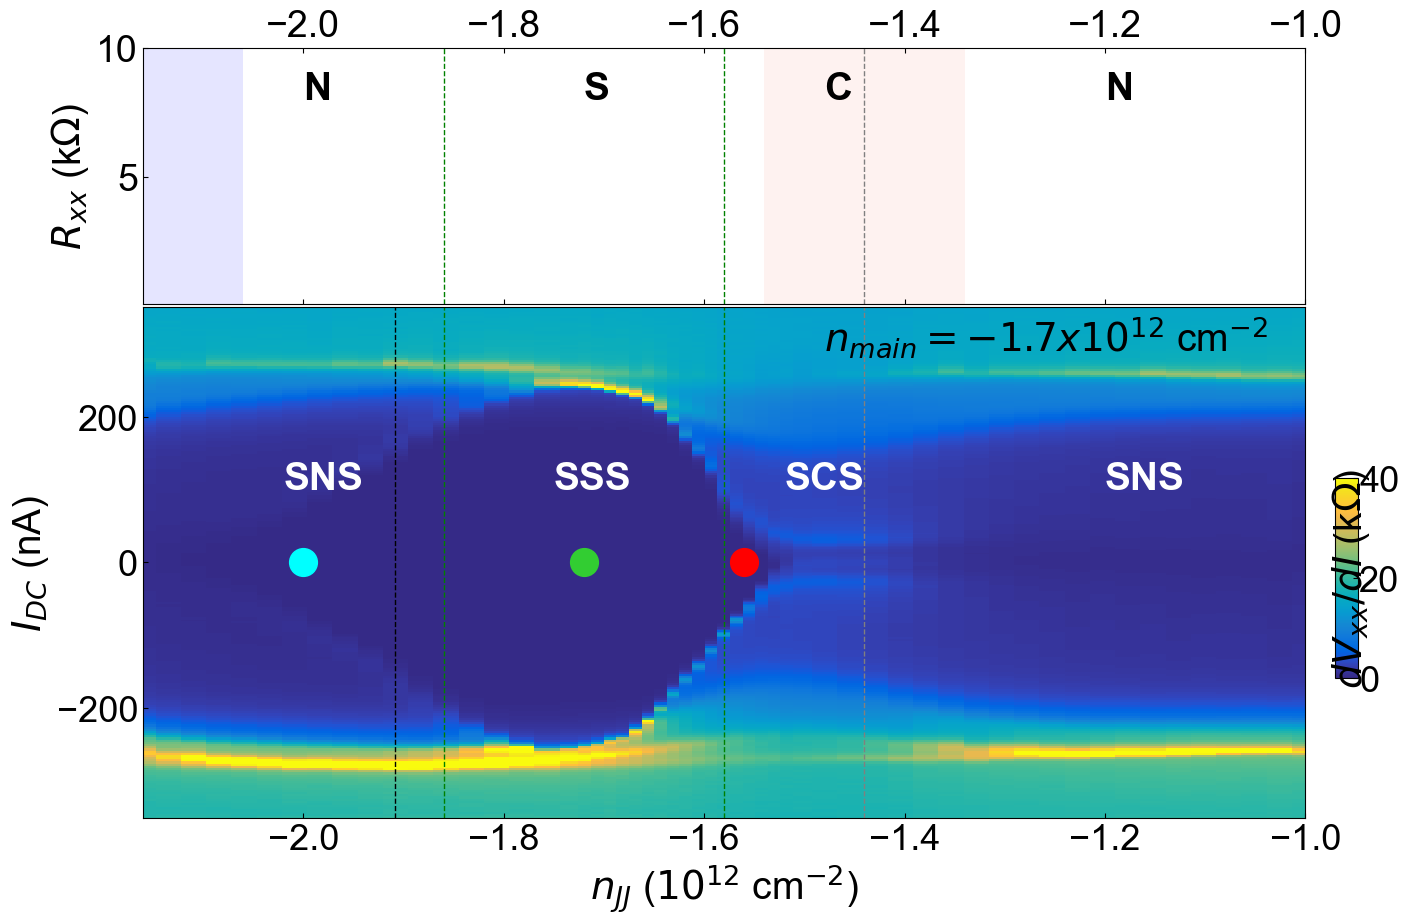

In [88]:
cap=0.00185/1.602E-19/0.88
C_BG=0.00185/1.602E-19/0.88
C_TG=0.00185/1.602E-19
C_TGjj=0.00185/1.602E-19/25

CNP=0.13
CNP_main=0.06
ns=2.88

font=26

if savecount==0:
    save=True
else:
    save=False 
# Fig params to save and color 

yTG=(-1.25-VBg_JJ2)/0.88

n_JJ2=((VBg_JJ2-CNP_main)*C_BG+yTG*C_TGjj)/1E16 #given in cm^-2

n_main2=((VBg_JJ2-CNP_main)*C_BG+yTG*C_TG)/1E16

linefits=True
if savecount==0:
    save=True
else:
    save=False

# terrain looks cool
#orig_cmap = matplotlib.cm.turbo
orig_cmap = parula_map
mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap,start=0,stop=1)

# Start the figure 
fig,axs=plt.subplots(2,gridspec_kw={'height_ratios': [1, 2]},figsize=(15,10))
plt.subplots_adjust(hspace=0.01)

ax=axs[1]



#fig = plt.figure(figsize=(15,6))

#ax = plt.subplot(111)


im = ax.pcolormesh(n_JJ2,DC_JJ2,Rxx1517_JJ2,cmap=mycolor,vmax=40,vmin=0)

ax.set_xlabel('$n_{JJ}$ ($10^{12}$ cm$^{-2}$)',fontsize=font+2)
ax.set_ylabel('$I_{DC}$ (nA)',fontsize=font+2)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='both', labelsize=font,direction='in')

### Add the colorbar 
cbaxes = fig.add_axes([0.92, 0.25, 0.015,0.2]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='vertical') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font+2,position=(-0.3,1.6), labelpad=-50,rotation=90)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in',pad=1)

ax.set_xlim(-2.16,-1)

# Make the double axis 
'''
ax2 = ax.twiny()
ax2.set_xlabel('$V_{BG}$ (V)',fontsize=14)
ax2.set_xlim(ax.get_xlim())
ax2.tick_params(axis='both', which='major', labelsize=font-1,direction='in')
# apply a function formatter. Should be the back gate, so it should be the opposite of what i did on top
#((VBg_JJ2-CNP-1.25/25-VBg/25))
#formatter = mticker.FuncFormatter(lambda y_top, pos: '{:.2f}'.format(((y_top+CNP+(1.25+CNP)/0.88/25))/cap*1E16))
formatter = mticker.FuncFormatter(lambda y_top, pos: '{:.2f}'.format((y_top/C_BG*25*1E16-1.25+25*CNP_main)/26))
ax2.xaxis.set_major_formatter(formatter)
#ax2.xaxis.tick_bottom()
#ax2.xaxis.set_label_position('bottom') 
'''


#ax.set_title('$V_{TGs}=-(1.25+V_{BG})/0.88$',fontsize=font-1,position=(0.2,0.92))

#ax.text(-1.2,300,'$n_{main}=$'+'{0:.2f}'.format((-1.25-CNP_main)*cap/1E16)+'x$10^{12}$ cm$^{-2}$',fontsize=font+2)
#ax.text(-2.1,-320,'$n_s=2.82$ cm$^{-2}$',fontsize=font-1)

#ax.text(-(ns/2),-320,r'$\nu=-2$',fontsize=font)
ax.axvline(x=-(ns/2),linestyle='dashed',color='grey',linewidth=1)

#ax.text(-(ns/4)-0.15,-320,r'$\nu=-1$',fontsize=font)
#ax.axvline(x=-(ns/4),linestyle='dashed',color='grey',linewidth=1)


ax.axvline(x=-1.58,linestyle='dashed',color='g',linewidth=1)
ax.axvline(x=-1.86,linestyle='dashed',color='g',linewidth=1)
#ax.axvline(x=((-1.25-CNP_main)*C_BG)/1E16,linestyle='dashed',color='g',linewidth=1)


ax.text(-1.75,100,'SSS',color='w',fontsize=font+2,weight='bold')
ax.text(-2.02,100,'SNS',color='w',fontsize=font+2,weight='bold')
ax.text(-1.2,100,'SNS',color='w',fontsize=font+2,weight='bold')
ax.text(-1.52,100,'SCS',color='w',fontsize=font+2,weight='bold')
ax.text(-1.48,290,'$n_{main}=$'+'${0:.1f}$'.format((-1.25-CNP_main)*cap/1E16)+'$x10^{12}$ cm$^{-2}$',fontsize=font+2,color='k')
#ax.set_ylim(-50,50)
#ax.text(-1.53,100,'SNcS',color='w',fontsize=18,weight='bold')
#ax.set_xlim(-2.82,0)

# Markers for the Fraunhofers 
ax.plot(-2,0,'aqua',marker='o',markersize=20)
ax.plot(-1.72,0,'limegreen',marker='o',markersize=20)
#ax.plot(-1.59,0,'magenta',marker='o',markersize=15)
ax.plot(-1.56,0,'r',marker='o',markersize=20)

#plt.tight_layout()
ax2=axs[0]
count=0
#for i in range(1,num_plot-1,2):  
for i in range(1,2):      
    #plt.plot((Bc1_BG[i]-0.055)*cap/1E16,Bc1_Rxx1[i],label='$B$'+'={0:.2f}'.format(Bc1_B[i,0]),color=colors[count])
    #ax2.plot((Bc1_BG[i]-0.055)*cap/1E16,Bc1_Rxx1[i],label='$B$'+'={0:.2f}'.format(Bc1_B[i,0]),color=colors[count])
    count=count+1
    
#ax2.plot((x_35[20:-12]-0.055)*cap/1E16,y_35[20:-12],label='$B$'+'={0:.2f}'.format(Bc1_B[0,0]),color='r')
#ax2.plot((x_35-0.055)*cap/1E16,y_35R,label='$B$'+'={0:.2f}'.format(Bc1_B[0,0]),color='k')
ax2.set_ylabel('$R_{xx}$ (k$\Omega$)',fontsize=font+2)
#ax2=ax1.twinx()
ax2.set_xlim(-2.16,-1)
ax2.set_ylim(0.1,10)
#ax2.set_yscale('log')
#ax2.xaxis.set_visible(False)
ax2.tick_params(axis='both', which='both', labelsize=font+1,direction='in')
ax2.tick_params(axis='x',which='both', bottom=True,top=True,labelbottom=False,labeltop=True)
ax2.tick_params(axis='y',which='both', left=True,right=False)
ax2.text(-2,8,'N',weight='bold',fontsize=font+2)
ax2.text(-1.72,8,'S',weight='bold',fontsize=font+2)
ax2.text(-1.48,8,'C',weight='bold',fontsize=font+2)
ax2.text(-1.2,8,'N',weight='bold',fontsize=font+2)
#ax2.tick_params(axis='both', which='minor', labelsize=font+1,direction='in')

ax2.axvline(x=-(ns/2),linestyle='dashed',color='grey',linewidth=1)

line=10
ax.axvline(x=(n_JJ2[line,0]),linestyle='dashed',color='k',linewidth=1)
#ax2.axvline(x=-(ns/4),linestyle='dashed',color='grey',linewidth=1)

# The limits of the SC are really extracted from the Temperature dependance 
ax2.axvline(x=-1.58,linestyle='dashed',color='g',linewidth=1)
ax2.axvline(x=-1.86,linestyle='dashed',color='g',linewidth=1)
ax2.axvspan((-ns/2)-0.1, (-ns/2)+0.1, facecolor='salmon',alpha=0.1)
ax2.axvspan((-ns/4*3)-0.1, (-ns/4*3)+0.1, facecolor='b',alpha=0.1)

if save:
    plt.savefig(savename+'JJBF_JJline_noytopaxis_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


-1.7190869367835662
-1.5931080467597325


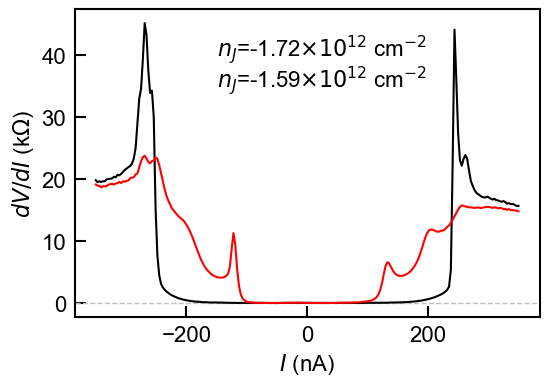

In [94]:
line=18
line2=28
line3=10
ax=plot_pre(6,4)
ax.axhline(y=0,linestyle='dashed',color='silver',linewidth=1)
ax.plot(DC_JJ2[line],Rxx1517_JJ2[line],'k')
ax.plot(DC_JJ2[line2],Rxx1517_JJ2[line2],'r')
#ax.plot(DC_JJ2[line3],Rxx1517_JJ2[line3],'dodgerblue')
plot_line(ax,xlabel='$I$ (nA)',ylabel='$dV/dI$ (k$\Omega$)')
ax.text(-150,40,r'$n_J$=-1.72$\times10^{12}$ cm$^{-2}$',fontsize=16)
ax.text(-150,35,r'$n_J$=-1.59$\times10^{12}$ cm$^{-2}$',fontsize=16)
print(n_JJ2[line,0])
print(n_JJ2[line2,0])


# Fraunhofers 

In [12]:
importlib.reload(LDQM_dataplot)

dvdiF_directory = 'C:/jdiez_local/LDQM/a. Data/2021 May'
dvdiF_folder='/Ju1/SCS-Fraunhofers/'
dvdiF_directory= dvdiF_directory+dvdiF_folder

dvdiF_files=[
       'J-Ju1_Fraunhofer-SCS_35mK_1nA_I(7-18)_Rxx1Amplified(15-17)_Rxx2Amp(5-1)_VBg(-1p12V)_VTGs(-147mV)_m-B-Idc.txt',
             'J-Ju1_Fraunhofer_SCS_Bdn_35mK_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Vtgs(-147mV)_Vbg(-1p12V)_mB_Idc.txt',
             'J-Ju1_Fraunhofer_SCS_Bdn_35mK_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Vtgs(-147mV)_Vbg(-1p12V)_mB_Idc_2.txt',
       'J-Ju1_Fraunhofer-SCS_35mK_1nA_I(7-18)_Rxx1Amplified(15-17)_Rxx2Amp(5-1)_VBg(-1p12V)_VTGs(-147mV)_B(0Tafter100mT)_Idc_updn.txt',
        'J-Ju1_Fraunhofer-SCS_35mK_1nA_I(7-18)_Rxx1Amplified(15-17)_Rxx2Amp(5-1)_VBg(-1p12V)_VTGs(-147mV)_B(0Tafter-100mT)_Idc_updn.txt',
]


dvdiF_obj = {} #stores all the data
dvdi_raw ={} #store the xaxis data for plotting
dvdiF_variables={} #store the data to plot in the right units
dvdiF_name={}

# All IV curves
for i in range(0,3):
    file=dvdiF_directory+dvdiF_files[i]
    dvdiF_obj['data'+str(i)], dvdiF_variables['data'+str(i)],dvdiF_name['data'+str(i)]=LDQM_dataplot.plot_map_fromfiles(file)
for i in range(3,5):
    file=dvdiF_directory+dvdiF_files[i]
    dvdiF_obj['data'+str(i)], dvdiF_variables['data'+str(i)],dvdiF_name['data'+str(i)]=LDQM_dataplot.plot_lines_fromfiles(file,x_variable=1)
    

C:\Users\jdiez_local\AppData\Local\Temp\ipykernel_30752\4149575901.py:41: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = plt.pcolormesh(y,x,z1517,cmap=mycolor)


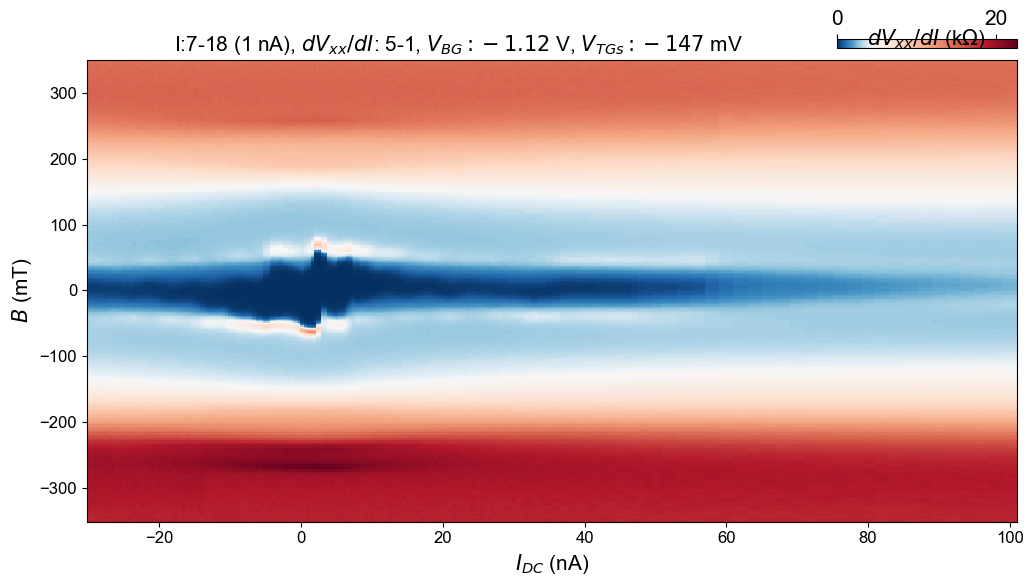

C:\Users\jdiez_local\AppData\Local\Temp\ipykernel_30752\4149575901.py:71: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = plt.pcolormesh(x,y,z51,cmap=mycolor)


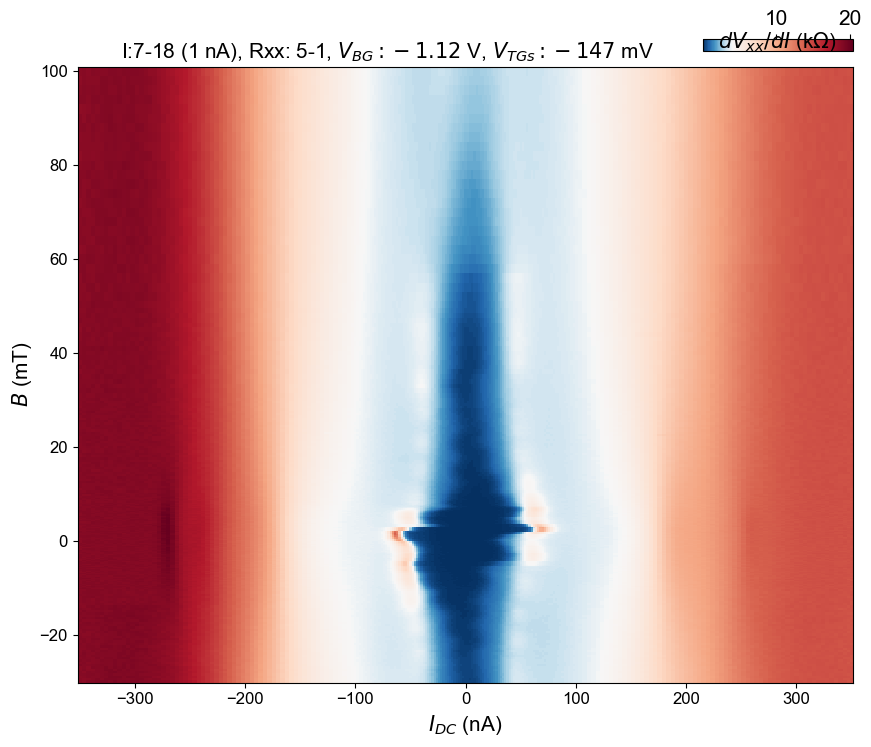

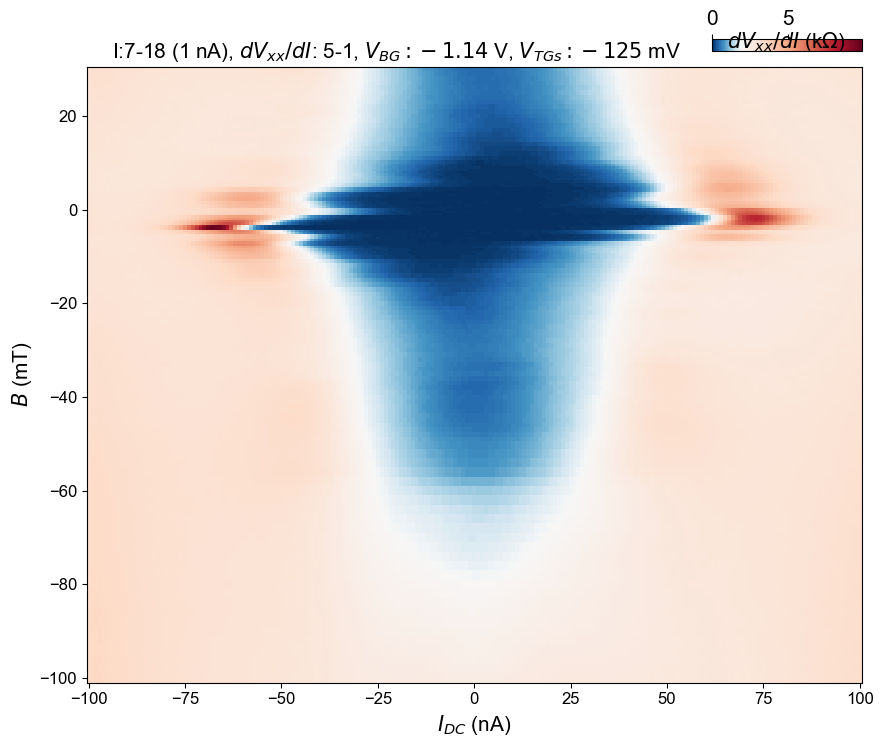

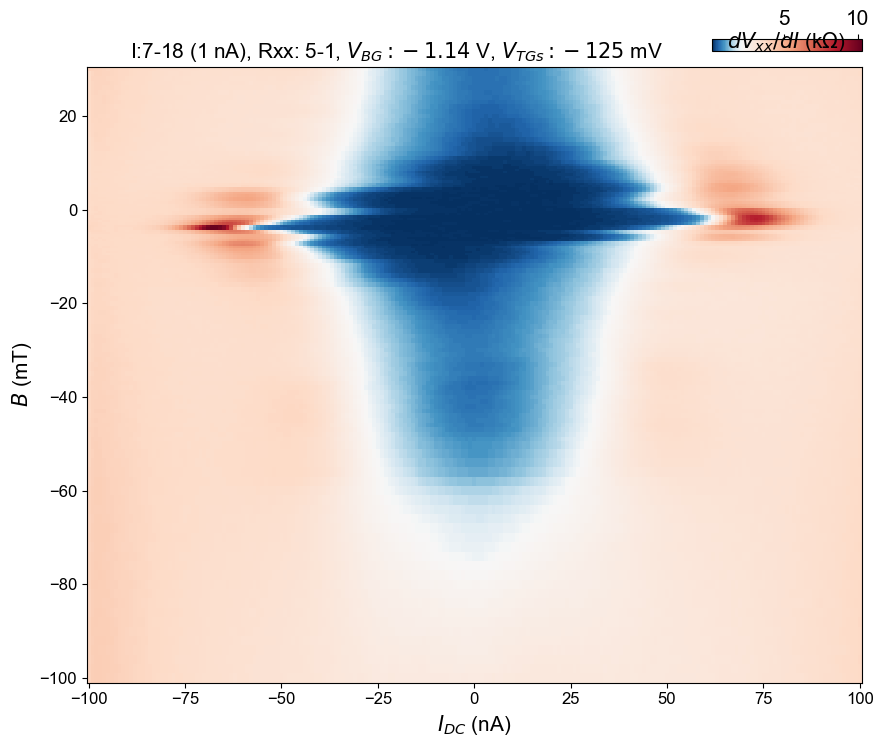

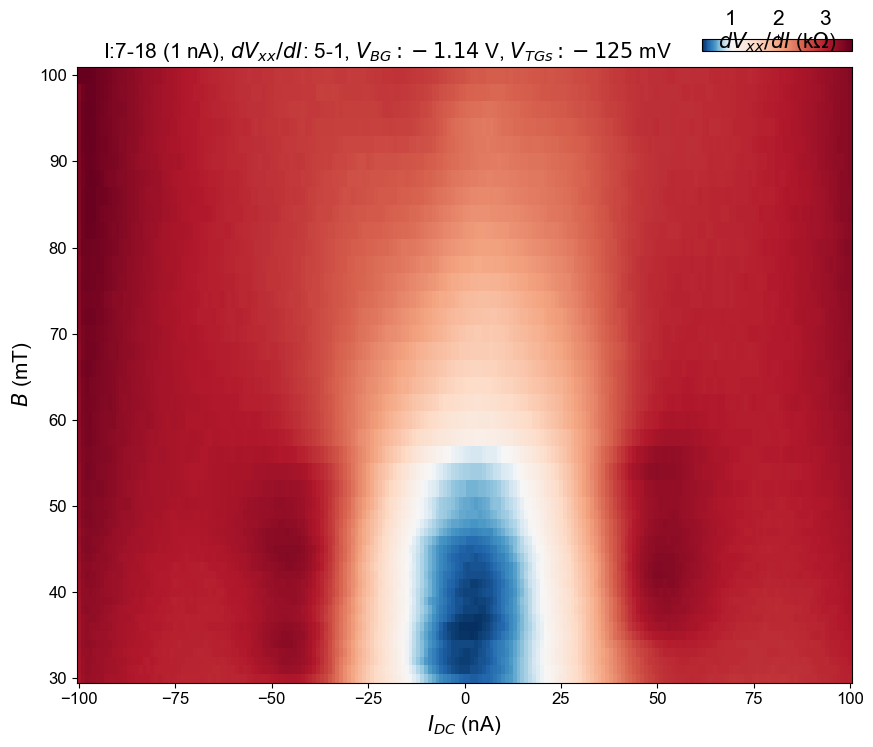

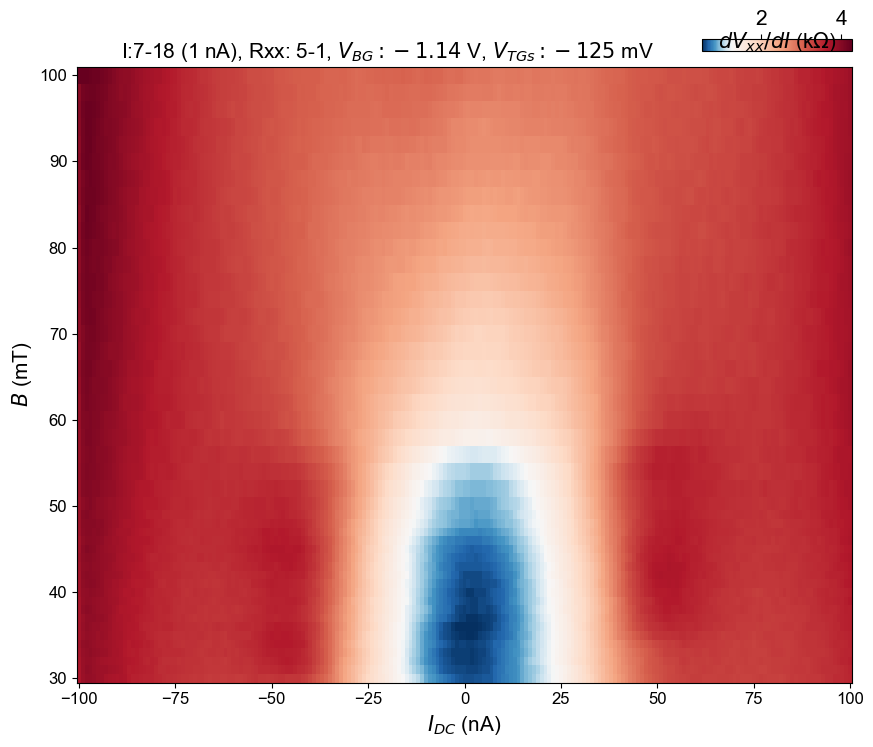

In [15]:
savecount=1
# Data
x=dvdiF_obj['data0'].DCsource1V100nASourcevoltage*100 # in nA
y=dvdiF_obj['data0'].MagnetFieldsetpoint*1000
yBG=-1.2-y*0.88 # in V
I718=dvdiF_obj['data0'].Rxx4X # in nA
z1517=dvdiF_obj['data0'].Rxx1_Ampx10X/I718/1000/10 # in kOhm
z51=dvdiF_obj['data0'].Rxx_2_Ampx10X/I718/1000/10 # in kOhm

x2=dvdiF_obj['data1'].DCSource1V100nASourcevoltage*100 # in nA
y2=dvdiF_obj['data1'].MagnetFieldsetpoint*1000
yBG2=-1.2-y*0.88 # in V
I7182=dvdiF_obj['data1'].Rxx4X # in nA
z15172=dvdiF_obj['data1'].Rxx1_Ampx10X/I7182/1000/10 # in kOhm
z512=dvdiF_obj['data1'].Rxx2_Ampx10X/I7182/1000/10 # in kOhm

x3=dvdiF_obj['data2'].DCSource1V100nASourcevoltage*100 # in nA
y3=dvdiF_obj['data2'].MagnetFieldsetpoint*1000
yBG3=-1.2-y*0.88 # in V
I7183=dvdiF_obj['data2'].Rxx4X # in nA
z15173=dvdiF_obj['data2'].Rxx1_Ampx10X/I7183/1000/10 # in kOhm
z513=dvdiF_obj['data2'].Rxx2_Ampx10X/I7183/1000/10 # in kOhm
# Fig params to save and color 

font = 15
linefits=True
if savecount==0:
    save=True
else:
    save=False
    
orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.2,orig_cmap)

# Start the figure 

fig = plt.figure(figsize=(12,6))

ax = plt.subplot(111)
im = plt.pcolormesh(y,x,z1517,cmap=mycolor)

ax.set_xlabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_ylabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=12)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.5,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

#ax.set_xlim(-2.2,1.4)

ax.set_title('I:7-18 (1 nA), $dV_{xx}/dI$: 5-1, $V_{BG}:-1.12$ V, $V_{TGs}:-147$ mV',fontsize=font,position=(0.4,0.92),color='k')

plt.show()

# Start the figure 

fig = plt.figure(figsize=(10,8))

ax = plt.subplot(111)
im = plt.pcolormesh(x,y,z51,cmap=mycolor)

ax.set_xlabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_ylabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=12)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.5,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

#ax.set_xlim(-2.2,1.4)

ax.set_title('I:7-18 (1 nA), Rxx: 5-1, $V_{BG}:-1.12$ V, $V_{TGs}:-147$ mV',fontsize=font,position=(0.4,0.92))

plt.show()


# Fig params to save and color 

font = 15
linefits=True
if savecount==0:
    save=True
else:
    save=False
    
orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.2,orig_cmap)

# Start the figure 

fig = plt.figure(figsize=(10,8))

ax = plt.subplot(111)
im = plt.pcolormesh(x2,y2,z15172,cmap=mycolor)

ax.set_xlabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_ylabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=12)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.5,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

#ax.set_xlim(-2.2,1.4)

ax.set_title('I:7-18 (1 nA), $dV_{xx}/dI$: 5-1, $V_{BG}:-1.14$ V, $V_{TGs}:-125$ mV',fontsize=font,position=(0.4,0.92),color='k')

plt.show()

# Start the figure 

fig = plt.figure(figsize=(10,8))

ax = plt.subplot(111)
im = plt.pcolormesh(x2,y2,z512,cmap=mycolor)

ax.set_xlabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_ylabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=12)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.5,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

#ax.set_xlim(-2.2,1.4)

ax.set_title('I:7-18 (1 nA), Rxx: 5-1, $V_{BG}:-1.14$ V, $V_{TGs}:-125$ mV',fontsize=font,position=(0.4,0.92))

plt.show()

### Going field the other way

# Start the figure 

fig = plt.figure(figsize=(10,8))

ax = plt.subplot(111)
im = plt.pcolormesh(x3,y3,z15173,cmap=mycolor)

ax.set_xlabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_ylabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=12)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.5,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

#ax.set_xlim(-2.2,1.4)

ax.set_title('I:7-18 (1 nA), $dV_{xx}/dI$: 5-1, $V_{BG}:-1.14$ V, $V_{TGs}:-125$ mV',fontsize=font,position=(0.4,0.92),color='k')

plt.show()

# Start the figure 

fig = plt.figure(figsize=(10,8))

ax = plt.subplot(111)
im = plt.pcolormesh(x3,y3,z513,cmap=mycolor)

ax.set_xlabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_ylabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=12)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.5,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

#ax.set_xlim(-2.2,1.4)

ax.set_title('I:7-18 (1 nA), Rxx: 5-1, $V_{BG}:-1.14$ V, $V_{TGs}:-125$ mV',fontsize=font,position=(0.4,0.92))

plt.show()

In [16]:
kb=1.38E-23/1.602E-19 # in eV
gap=kb*1.76*1.5
gap
Ic=1200E-9
Rn=0.8E3

Ic*Rn/gap


4.221343873517785

In [25]:
savecount=1

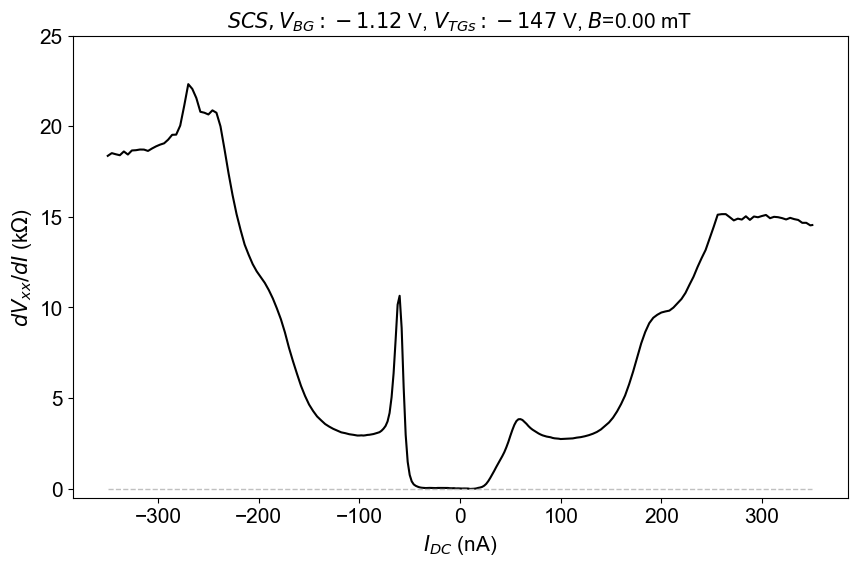

In [17]:
# Plot the line at 0 field 
plt.figure(figsize=(10,6))
line=125
plt.plot(x[line],z1517[line],'k',label='$SCS, V_{BG}:-1.12$ V, $V_{TGs}:147$ mV, $B$='+'{0:.2f}'.format(y[line,0])+' mT')

#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.9), shadow=False, ncol=1,fontsize=font)
plt.title('$SCS, V_{BG}:-1.12$ V, $V_{TGs}:-147$ V, $B$='+'{0:.2f}'.format(y[line,0])+' mT' ,fontsize=font,position=(0.5,0.9))
plt.xlabel('$I_{DC}$ (nA)',fontsize=font)
plt.ylabel('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font)
plt.tick_params(labelsize=font)
plt.ylim(-0.5,25)
#plt.xlim(-30,+30)
plt.plot(x[0],x[0]*0,'silver',linestyle='dashed',linewidth=1)

if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SCS_-Vbg-1p12_VTgs147V_0Bline_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()

C:\Users\jdiez_local\AppData\Local\Temp\ipykernel_30752\2083828377.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = plt.pcolormesh(y,x,z1517,cmap=mycolor,vmax=8,vmin=0)


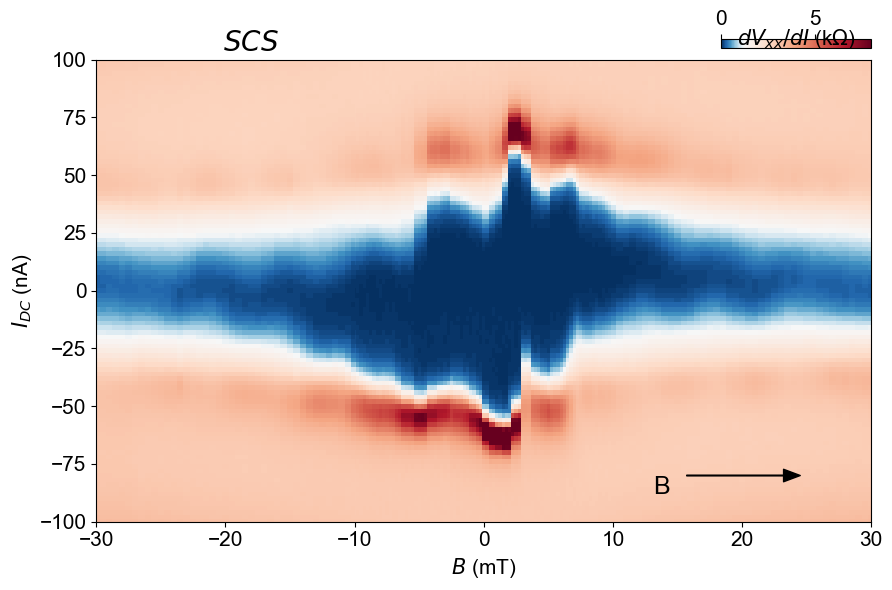

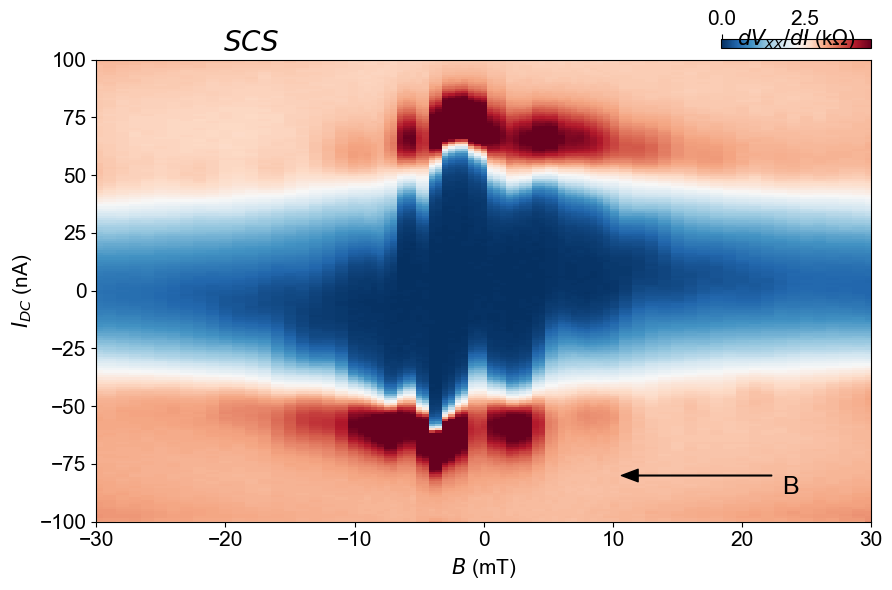

In [18]:
if savecount==0:
    save=True
else:
    save=False

orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.15,orig_cmap,0,1)

# Start the figure 
font=15
fig = plt.figure(figsize=(10,6))

ax = plt.subplot(111)
im = plt.pcolormesh(y,x,z1517,cmap=mycolor,vmax=8,vmin=0)
#im = plt.pcolormesh(x,y,z1517,cmap=mycolor,vmax=5,shading='gouraud')
ax.set_ylabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_xlabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=font)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.7,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

ax.set_ylim(-100,100)
ax.set_xlim(-30,30)

ax.set_title('$SCS$' ,fontsize=20,position=(0.2,0.9))
ax.annotate('B ', xy=(25,-80),xytext=(15, -80), arrowprops=dict(facecolor='black',width=0.5,headwidth=9, shrink=0.05),horizontalalignment='right', verticalalignment='top',fontsize=18)
if save:
    plt.savefig(savename+'JJBF_SCS_Vbg-1p12_Bup_I7-18_Rxx1517_lowBfocus'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()
orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap,0,1)

# Start the figure 
savecount=savecount-1
fig = plt.figure(figsize=(10,6))

ax = plt.subplot(111)
im = plt.pcolormesh(y2,x2,z15172,cmap=mycolor,vmax=4.5)
#im = plt.pcolormesh(x,y,z1517,cmap=mycolor,vmax=5,shading='gouraud')
ax.set_ylabel('$I_{DC}$ (nA)',fontsize=font)
ax.set_xlabel('$B$ (mT)',fontsize=font)

#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=font)

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font,position=(-0.7,1), labelpad=-15,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font)

ax.set_ylim(-100,100)
ax.set_xlim(-30,30)
ax.set_title('$SCS$' ,fontsize=20,position=(0.2,0.9))
ax.annotate('B ', xy=(10,-80),
            xytext=(25, -80),
            arrowprops=dict(facecolor='black',width=0.5,headwidth=9, shrink=0.05),
            horizontalalignment='right', verticalalignment='top',fontsize=18
            )
if save:
    plt.savefig(savename+'JJBF_SCS_-Vbg1p12_Bdn_I7-18_Rxx1517_lowBfocus'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()

In [4491]:
%matplotlib inline

datasets=JJ_files
dev_name = 'Ju1 '
x_data=1
y_data=0
fontleg=12
font=15
hd=0
I_name='Rxx4X'
label_off=''
I_mult=1
x_conversion=1



def interactive_map_linescans_x(dataset=1, plot_data=2, plot_axis=0, #x axis is 0 and y axis is 1 
                        x_st=0 ,x_ext=5, x_int=1, offset=0, 
                        label_int=1,
                        label_y='',label_x='', title_label='',
                        leg_label='', 
                        x_min=0,x_max=0,y_min=0,y_max=0, hor_point=0,    zero_line=True ,
                        x_figsize=15,y_figsize=6,x_conversion=1,
                        save=False, conduc=False, eh=False,norm_current=False,norm_quantum=False,
                        log_bool=False,abs_bool=False,legend=True,background=False,
                        expand=10):
    if plot_axis==0:
        line_marker=''
    else: 
        line_marker='o'
    #Choose the device you want to plot
    scan_names=dvdiF_variables['data'+str(dataset)]
    data_obj=dvdiF_obj['data'+str(dataset)]

    x_name=scan_names[x_data]
    y_name=scan_names[y_data]
    z_name=scan_names[plot_data]
    
    file=dvdiF_files[dataset]
    
    LDQM_dataplot.make_int_linescans(file,plot_axis,data_obj,z_name,x_name, y_name,I_name,dev_name,
            x_st ,x_ext, x_int, offset,   label_int,                   
            label_y,label_x, title_label,
            leg_label,x_min,x_max,y_min,y_max,line_marker,zero_line,
                       hor_point,x_figsize,y_figsize,
            save, conduc, eh,norm_current,norm_quantum,
            log_bool,abs_bool,legend,background,x_conversion, expand,I_mult,
            font,fontleg,hd)
    
    
interactive(interactive_map_linescans_x, dataset=(0,10,1), plot_data=(0,15,1), 
            x_st=(0,1000,1),x_ext=(0,1000,1),x_int=(0,1000,1),offset=(-10,10,0.001),
            label_int=(0,100,1),
            x_min=(-100,100,0.001),x_max=(-10000,10000,0.001),y_min=(-100,100,0.0001),y_max=(-100,100,0.0001),
           expand=(0,10000000,1),x_conversion=(0,1000,0.0001))

interactive(children=(IntSlider(value=1, description='dataset', max=10), IntSlider(value=2, description='plot_…

# Plot the 0 field state after going to up and down fields

In [40]:
savecount=1

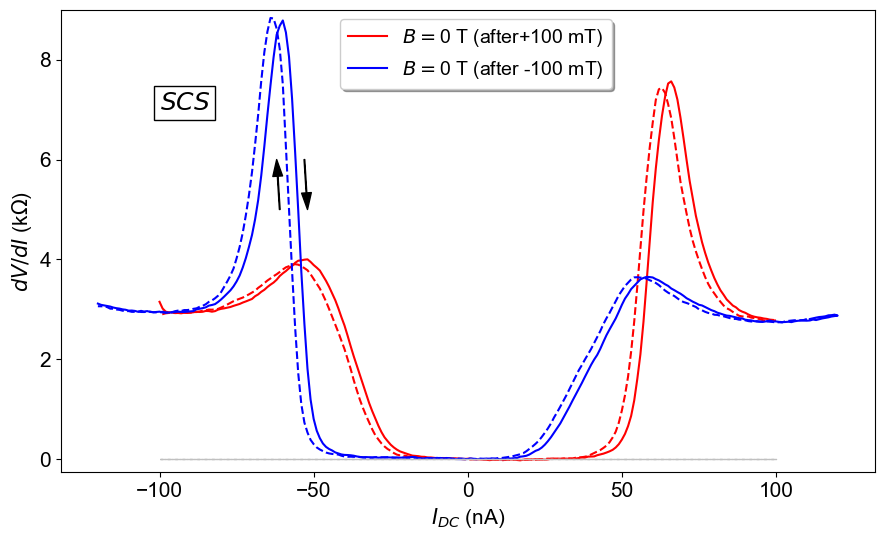

area red right =195.64481392143816 $\mu V$, area red left 204.070522698254
area blue right =209.28516445047214 $\mu V$, area blue left 218.0350754775205
$I_cR_N$ is 300uV


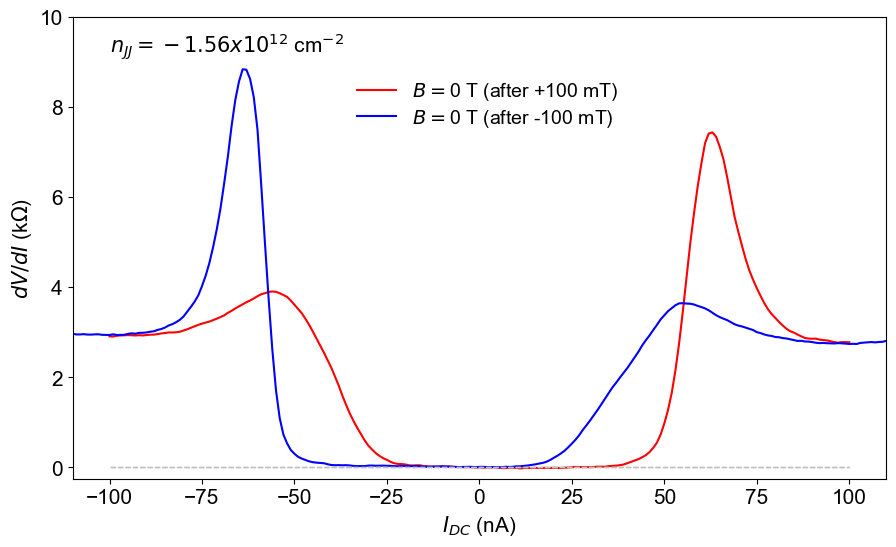

In [19]:
# Data
x1=dvdiF_obj['data3'].DCsource1V100nASourcevoltage*100 # in nA
I7181=dvdiF_obj['data3'].Rxx4X # in nA
z15171=dvdiF_obj['data3'].Rxx1_Ampx10X/I7181/1000/10 # in kOhm
z511=dvdiF_obj['data3'].Rxx_2_Ampx10X/I7181/1000/10 # in kOhm

x2=dvdiF_obj['data4'].DCsource1V100nASourcevoltage*100 # in nA
I7182=dvdiF_obj['data4'].Rxx4X # in nA
z15172=dvdiF_obj['data4'].Rxx1_Ampx10X/I7182/1000/10 # in kOhm
z512=dvdiF_obj['data4'].Rxx_2_Ampx10X/I7182/1000/10 # in kOhm

# Fig params to save and color 

font = 15

if savecount==0:
    save=True
else:
    save=False
    
orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap,0,1)

# Start the figure 

fig = plt.figure(figsize=(10.5,6))

plt.plot(x1[:200],z15171[:200],'r',label='$B= $0 T (after+100 mT)')
plt.plot(x1[200:],z15171[200:],'r--')
plt.plot(x2[:250],z15172[:250],'b',label='$B= $0 T (after -100 mT)')
plt.plot(x2[250:],z15172[250:],'b--')
plt.legend(loc='upper center', bbox_to_anchor=(0.51,1.0), shadow=True, ncol=1,fontsize=14)
plt.xlabel('$I_{DC}$ (nA)',fontsize=font)
plt.ylabel('$dV/dI$ (k$\Omega$)',fontsize=font)
#plt.title('$I:7-18, R_{xx}: 17-15, V_{BG}=-1.25, V_{TG}=-0$ V',fontsize=14)
plt.text(-100, 7,'$SCS$',color='k',fontsize=18,weight='bold',bbox=dict(facecolor='w',edgecolor='k'))
plt.ylim(-0.25,9)
plt.annotate('', xy=(-52,5),
            xytext=(-53, 6),
            arrowprops=dict(color='k',width=0.5,headwidth=7),
            horizontalalignment='right', verticalalignment='top',fontsize=18,color='k'
            )
plt.annotate('', xy=(-62,6),
            xytext=(-61, 5),
            arrowprops=dict(color='k',width=0.5,headwidth=7),
            horizontalalignment='right', verticalalignment='top',fontsize=18,color='k'
            )
#plt.xlim(-50,+50)
plt.tick_params(axis='both', which='major', labelsize=font)
plt.plot(x1,x1*0,'silver',linestyle='dashed',linewidth=1)

if save:
    plt.savefig(savename+'JJBF_SCS_-Vbg1p12_dVdI_after+-100mT_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()


# Compute the area using the composite simpons method and compare to IcRn.
IcRn=100*3

area_redrigth = simps(z15171[100:200],x1[100:200])
area_redleft = simps(z15171[5:100],x1[5:100])

area_bluerigth = simps(z15172[120:225],x2[120:225])
area_blueleft = simps(z15172[20:120],x2[20:120])

print('area red right ='+str(area_redrigth)+' $\mu V$, area red left ' +str(area_redleft))
print('area blue right ='+str(area_bluerigth)+' $\mu V$, area blue left ' +str(area_blueleft))
print('$I_cR_N$ is '+str(IcRn)+'uV')

# Start the figure 

fig = plt.figure(figsize=(10.5,6))

#plt.plot(x1[:200],z15171[:200],'r',label='$B= $0 T (after +100 mT)')
plt.plot(x1[200:],z15171[200:],'r-',label='$B= $0 T (after +100 mT)')
#plt.plot(x2[:250],z15172[:250],'b',label='$B= $0 T (after -100 mT)')
plt.plot(x2[250:],z15172[250:],'b-',label='$B= $0 T (after -100 mT)')
plt.legend(loc='upper center', bbox_to_anchor=(0.51,0.9), shadow=False, ncol=1,fontsize=14
           ,frameon=False,labelspacing=0.25)
plt.xlabel('$I_{DC}$ (nA)',fontsize=font)
plt.ylabel('$dV/dI$ (k$\Omega$)',fontsize=font)
#plt.title('$I:7-18, R_{xx}: 17-15, V_{BG}=-1.25, V_{TG}=-0$ V',fontsize=14)
plt.text(-100, 9.2,'$n_{JJ}=-1.56x10^{12}$ cm$^{-2}$',color='k',fontsize=font)

plt.ylim(-0.25,10)

plt.xlim(-110,+110)
plt.tick_params(axis='both', which='major', labelsize=font)
plt.plot(x1,x1*0,'silver',linestyle='dashed',linewidth=1)

if save:
    plt.savefig(savename+'JJBF_SCS_-Vbg1p12_dVdI_after+-100mT_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()

In [21]:
importlib.reload(LDQM_dataplot)

dvdiF_directory3 = 'C:/jdiez_local/LDQM/a. Data/2021 May'
dvdiF_folder3='/Ju1/07_SNcS-SCS-SNS-Fraunhofers/'
dvdiF_directory3= dvdiF_directory3+dvdiF_folder3

dvdiF_files3=[
              'J-Ju1_Fraunhofer-SNS-SCS_35mK_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Vtgs(-1p25-xdiv0p88mV)_Vbg(-1p48-1p06)_m-B-Idc-1p48.txt',
              'J-Ju1_SSS_Fraunhofer_35mK_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Rxy(17-1)_Vtgs(-1p25-xdiv0p88mV)_Vbg(-1p25)_m_B_Idc.txt',
              'J-Ju1_Fraunhofer-SCS-aftercooldn_35mK_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Rxy(17-1)_VTGs(-Vbg-1p25)div0p88_Vbg(-1p12V)_m-B_Idc_full.txt'
              
]


dvdiF_obj3 = {} #stores all the data
dvdiF_variables3={} #store the data to plot in the right units
dvdiF_name3={}

for i in range(len(dvdiF_files3)):
    file=dvdiF_directory3+dvdiF_files3[i]
    dvdiF_obj3['data'+str(i)], dvdiF_variables3['data'+str(i)],dvdiF_name3['data'+str(i)]=LDQM_dataplot.plot_map_fromfiles(file)


# SNS- Vbg:-1.06V, VTGs:(-1.25+Vbg)/0.88

In [45]:
dvdiF_name3['data0']

'J-Ju1_Fraunhofer-SNS-SCS_35mK_I(7-18)_Rxx1(15-17)_Rxx2(5-1)_Vtgs(-1p25-xdiv0p88mV)_Vbg(-1p48-1p06)_m-B-Idc-1p48.txt'

In [3775]:
savecount=0

In [22]:
# 2D Jj correct with Bessel function
def Is2D(Ic,B,w):
    h=4*w**2*B/phi_0   # Reduced field. Eq. 9 of Moshe Paper 
    # a0 is 0.43
    return Ic*abs(scipy.special.jv(0, 0.43*h))


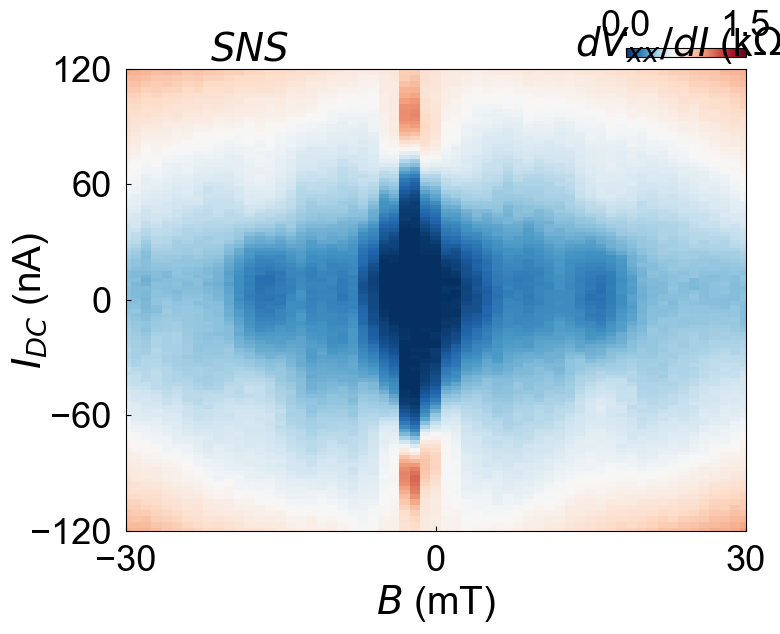

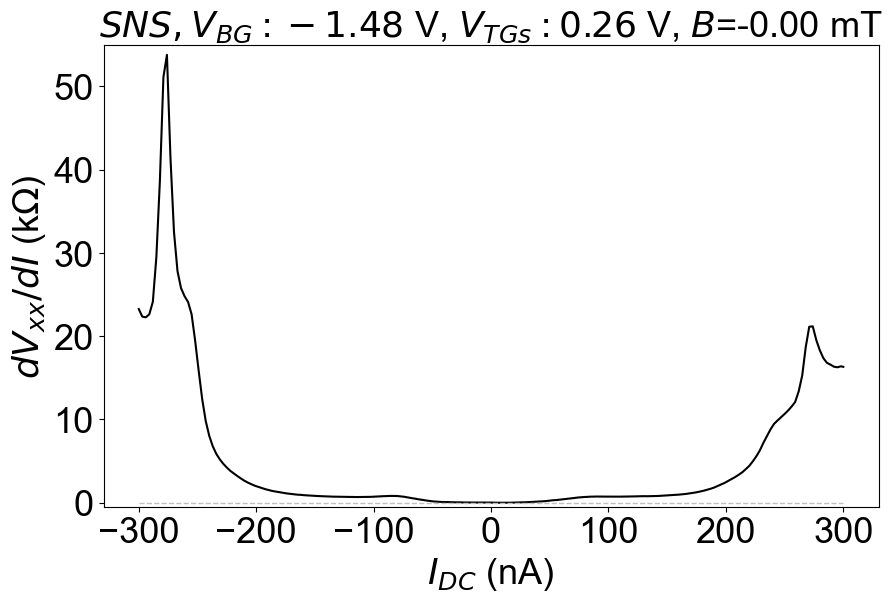

In [23]:

# Data
num=0
x=dvdiF_obj3['data'+str(num)].DCSource1V100nASourcevoltage*100 # in nA
y=dvdiF_obj3['data'+str(num)].MagnetFieldsetpoint*1000
yBG=-1.2-y*0.88 # in V
I718=dvdiF_obj3['data'+str(num)].Rxx4X # in nA
z1517=dvdiF_obj3['data'+str(num)].Rxx1_Ampx10X/I718/1000/10 # in kOhm
z51=dvdiF_obj3['data'+str(num)].Rxx2_Ampx10X/I718/1000/10 # in kOhm

# Fig params to save and color 

font = 26

if savecount==0:
    save=True
else:
    save=False
    
orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.4,orig_cmap)

fig = plt.figure(figsize=(8,6))

ax = plt.subplot(111)
im = plt.pcolormesh(y,x,z1517,cmap=mycolor,vmin=0,vmax=1.5)

ax.set_ylabel('$I_{DC}$ (nA)',fontsize=font+2,labelpad=-15)
ax.set_xlabel('$B$ (mT)',fontsize=font+2)
#ax.yaxis.set_label_coords(-0.1,0.5)
#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax.tick_params(axis='both', which='major', labelsize=font,direction='in',pad=10)
ax.set_xticks([-60,-30,0,30,60])
ax.set_yticks([-120,-60,0,120,60])
### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font+2,position=(-0.75,1), labelpad=-24,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')
cb.set_ticks([0,1.5])
ax.set_ylim(-120,120)
ax.set_xlim(-30,30)
#ax.set_title('$SNcS$ $V_{BG}:-1.12$ V, $V_{TGs}:-147$ mV',fontsize=font,position=(0.45,0.92),color='k',bbox=dict(facecolor='w',edgecolor='k'))
ax.set_title('$SNS$',fontsize=font+2,position=(0.2,0.85),color='k',weight='bold')

ax.plot(-44,100,'aqua',marker='o',markersize=20)
'''
ax.annotate('B ', xy=(80,-140),
            xytext=(50, -140),
            arrowprops=dict(facecolor='black',width=0.5,headwidth=9, shrink=0.05),
            horizontalalignment='right', verticalalignment='top',fontsize=font+2
            )
'''
if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SNS_Vbg-1p48_focus_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
plt.show()

# Plot the line at 0 field
plt.figure(figsize=(10,6))
line=58
plt.plot(x[line],z1517[line],'k',label='$B$='+'{0:.2f}'.format(y[line,0])+' mT')


#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.9), shadow=False, ncol=1,fontsize=font)
plt.title('$SNS, V_{BG}:-1.48$ V, $V_{TGs}:'+'{0:.2f}'.format(-(-1.48+1.25)/0.88)+'$ V, $B$='+'{0:.2f}'.format(y[line,0])+' mT' ,fontsize=font,position=(0.5,0.9))

plt.xlabel('$I_{DC}$ (nA)',fontsize=font)
plt.ylabel('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font)
plt.tick_params(labelsize=font)
plt.ylim(-0.5,55)
#plt.xlim(-30,+30)
plt.plot(x[0],x[0]*0,'silver',linestyle='dashed',linewidth=1)
if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SNS_Vbg-1p48_0Bline_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()


# SSS

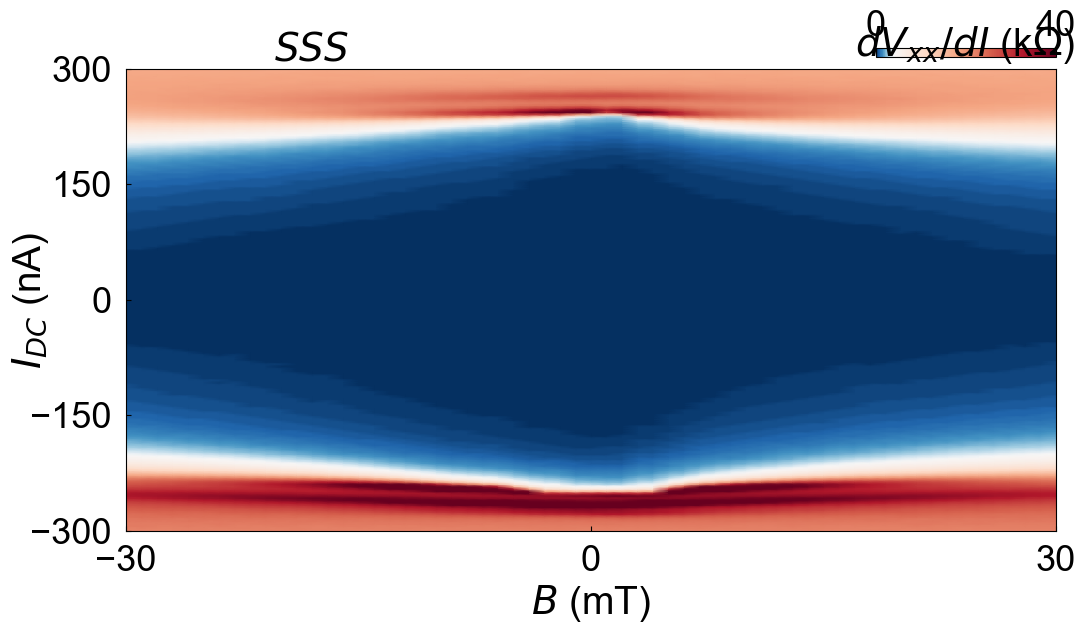

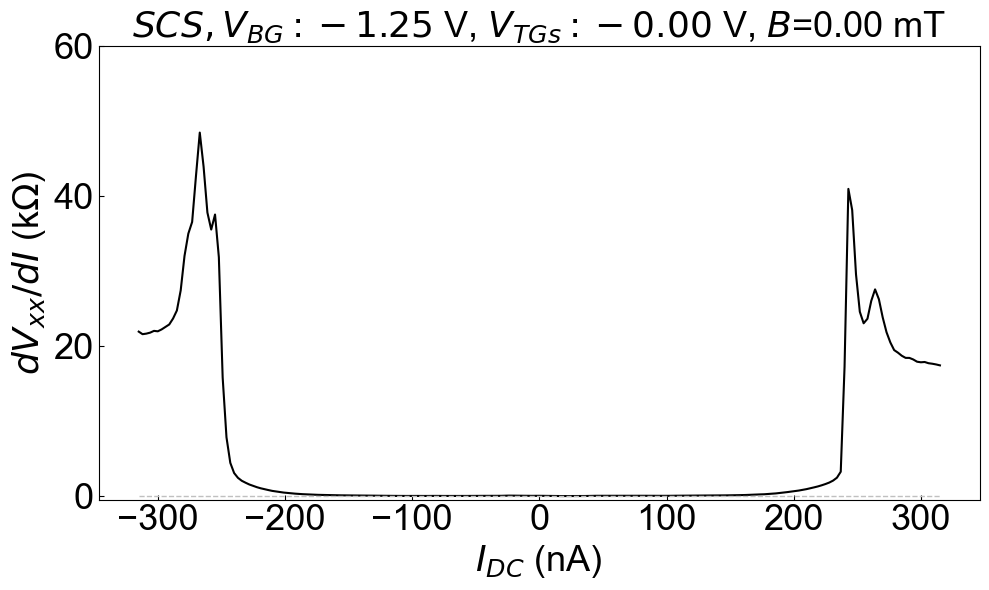

In [24]:
savecount=1
# Data
num=1

x=dvdiF_obj3['data'+str(num)].DCSource1V100nASourcevoltage*100 # in nA
y=dvdiF_obj3['data'+str(num)].MagnetFieldsetpoint*1000
yBG=-1.2-y*0.88 # in V
I718=dvdiF_obj3['data'+str(num)].Rxx4X # in nA
z1517=dvdiF_obj3['data'+str(num)].Rxx1_Ampx10X/I718/1000/10 # in kOhm
z51=dvdiF_obj3['data'+str(num)].Rxx2_Ampx10X/I718/1000/10 # in kOhm

# Fig params to save and color 

font = 26

if savecount==0:
    save=True
else:
    save=False
    
orig_cmap = matplotlib.cm.RdBu_r

#mycolor=LDQM_dataplot.shiftedColorMap(0.4,orig_cmap)

# Start the focused figure 

mycolor=LDQM_dataplot.shiftedColorMap(0.1,orig_cmap,division=1024)

fig = plt.figure(figsize=(12,6))

ax = plt.subplot(111)
im = plt.pcolormesh(y,x,z1517,cmap=mycolor,vmin=0,vmax=40,shading='gouraud')

ax.set_ylabel('$I_{DC}$ (nA)',fontsize=font+2,labelpad=-15)
ax.set_xlabel('$B$ (mT)',fontsize=font+2)


ax.tick_params(axis='both', which='major', labelsize=font,direction='in',pad=10)
ax.set_yticks([-300,-150,0,150,300])
#ax.set_xticks([-200,-100,0,100,200])
ax.set_xticks([-60,-30,0,30,60])
ax.set_ylim(-300,300)
ax.set_xlim(-30,30)
### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font+2,position=(-0.7,1), labelpad=-24,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')
cb.set_ticks([0,40])
#ax.set_xlim(-200,200)

#ax.set_title('$SNcS$ $V_{BG}:-1.12$ V, $V_{TGs}:-147$ mV',fontsize=font,position=(0.45,0.92),color='k',bbox=dict(facecolor='w',edgecolor='k'))
ax.set_title('$SSS$',fontsize=font+2,position=(0.2,0.85),color='k',weight='bold')
ax.plot(-45,237,'limegreen',marker='o',markersize=20)
'''
ax.annotate('B ', xy=(150,-210),
            xytext=(100, -210),
            arrowprops=dict(facecolor='black',width=0.5,headwidth=9, shrink=0.05),
            horizontalalignment='right', verticalalignment='top',fontsize=font+2
            )
'''
#ax.tight_layout()
if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SCS_-Vbg1p06_focus_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
plt.show()

# Plot the line at 0 field
plt.figure(figsize=(10,6))
line=63
plt.plot(x[line],z1517[line],'k',label='$B$='+'{0:.2f}'.format(y[line,0])+' mT')


#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.9), shadow=False, ncol=1,fontsize=font)
plt.title('$SCS, V_{BG}:-1.25$ V, $V_{TGs}:'+'{0:.2f}'.format(-(-1.25+1.25)/0.88)+'$ V, $B$='+'{0:.2f}'.format(y[line,0])+' mT' ,fontsize=font,position=(0.5,0.9))

plt.xlabel('$I_{DC}$ (nA)',fontsize=font)
plt.ylabel('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font)
plt.tick_params(labelsize=font,direction='in')
plt.ylim(-.5,60)
#plt.xlim(-30,+30)
plt.plot(x[0],x[0]*0,'silver',linestyle='dashed',linewidth=1)
plt.tight_layout()
if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SCS_-Vbg1p06_0Bline_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()




In [ ]:
plt.figure(figsize=(10,6))
line=63
plt.plot(x[line],z1517[line],'k',label='$B$='+'{0:.2f}'.format(y[line,0])+' mT')


#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.9), shadow=False, ncol=1,fontsize=font)
plt.title('$SCS, V_{BG}:-1.25$ V, $V_{TGs}:'+'{0:.2f}'.format(-(-1.25+1.25)/0.88)+'$ V, $B$='+'{0:.2f}'.format(y[line,0])+' mT' ,fontsize=font,position=(0.5,0.9))

plt.xlabel('$I_{DC}$ (nA)',fontsize=font)
plt.ylabel('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font)
plt.tick_params(labelsize=font,direction='in')
plt.ylim(-.5,60)
#plt.xlim(-30,+30)
plt.plot(x[0],x[0]*0,'silver',linestyle='dashed',linewidth=1)
plt.tight_layout()
if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SCS_-Vbg1p06_0Bline_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(-150, 45, '$n_J$=-1.72$\\times10^{12}$ cm$^{-2}$')

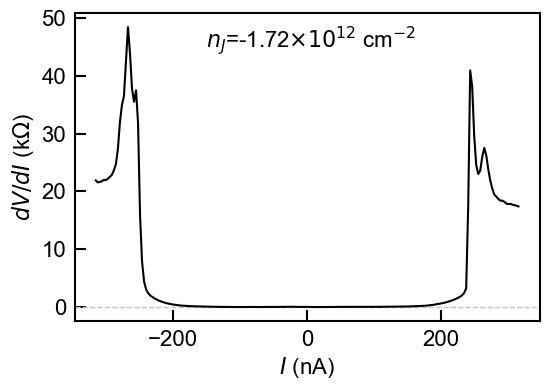

In [38]:
ax=plot_pre(6,4)
ax.axhline(y=0,linestyle='dashed',color='silver',linewidth=1)
ax.plot(x[line],z1517[line],'k')

plot_line(ax,xlabel='$I$ (nA)',ylabel='$dV/dI$ (k$\Omega$)')
ax.text(-150,45,r'$n_J$=-1.72$\times10^{12}$ cm$^{-2}$',fontsize=16)

# SCS

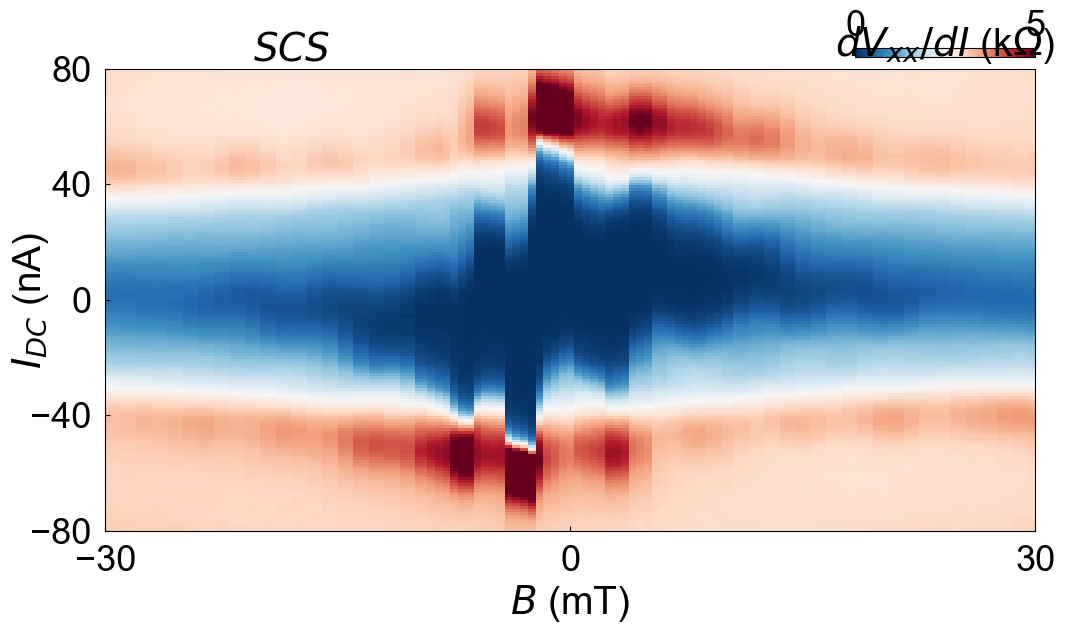

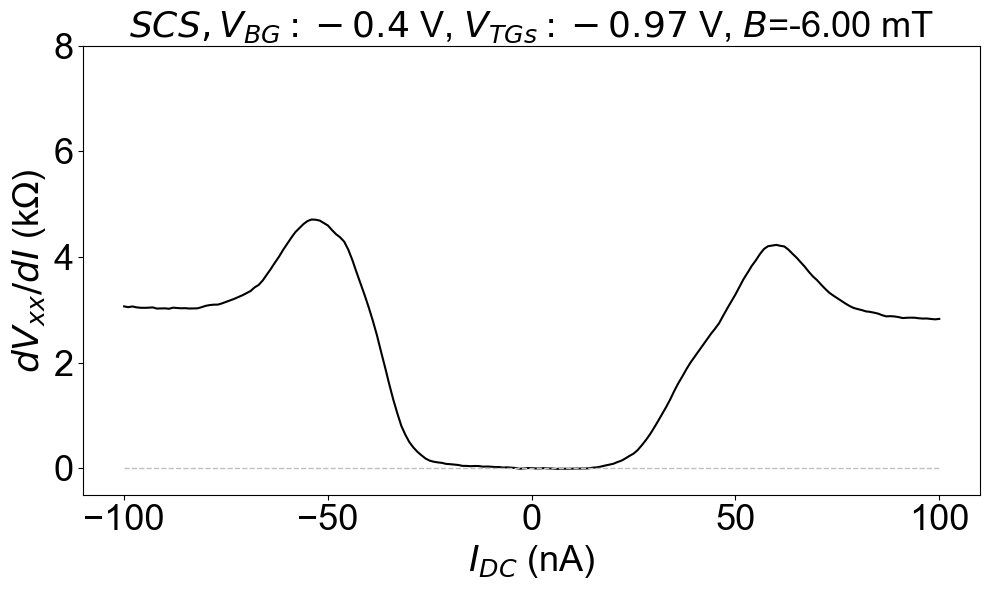

In [39]:
savecount=1
# Data
num=2

x=dvdiF_obj3['data'+str(num)].DCSource1V100nASourcevoltage*100 # in nA
y=dvdiF_obj3['data'+str(num)].MagnetFieldsetpoint*1000
yBG=-1.2-y*0.88 # in V
I718=dvdiF_obj3['data'+str(num)].Rxx4X # in nA
z1517=dvdiF_obj3['data'+str(num)].Rxx1_Ampx10X/I718/1000/10 # in kOhm
z51=dvdiF_obj3['data'+str(num)].Rxx2_Ampx10X/I718/1000/10 # in kOhm

# Fig params to save and color 

font = 26

if savecount==0:
    save=True
else:
    save=False
    
orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.4,orig_cmap)


###
# Start the focused figure 

mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap)

fig = plt.figure(figsize=(12,6))

ax = plt.subplot(111)
im = plt.pcolormesh(y,x,z1517,cmap=mycolor,vmin=0,vmax=5)

ax.set_ylabel('$I_{DC}$ (nA)',fontsize=font+2,labelpad=-15)
ax.set_xlabel('$B$ (mT)',fontsize=font+2)


ax.tick_params(axis='both', which='major', labelsize=font,direction='in',pad=10)
ax.set_xticks([-60,-30,0,30,60])
ax.set_yticks([-80,-40,0,40,80])

### Add the colorbar 
cbaxes = fig.add_axes([0.75, 0.90, 0.15,0.015]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font+2,position=(-0.7,1), labelpad=-24,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')

ax.set_xlim(-30,30)
ax.set_ylim(-80,80)

#ax.set_title('$SNcS$ $V_{BG}:-1.12$ V, $V_{TGs}:-147$ mV',fontsize=font,position=(0.45,0.92),color='k',bbox=dict(facecolor='w',edgecolor='k'))
ax.set_title('$SCS$',fontsize=font+2,position=(0.20,0.85),color='k',weight='bold')
ax.plot(-44,64,'r',marker='o',markersize=20)
'''
ax.annotate('B ', xy=(60,-80),
            xytext=(40, -80),
            arrowprops=dict(facecolor='black',width=0.5,headwidth=9, shrink=0.05),
            horizontalalignment='right', verticalalignment='top',fontsize=font+2
            )
'''
#ax.tight_layout()
if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SCS_-Vbg1p06_focus_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
plt.show()

# Plot the line at 0 field
plt.figure(figsize=(10,6))
line=63
plt.plot(x[line],z1517[line],'k',label='$B$='+'{0:.2f}'.format(y[line,0])+' mT')


#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 0.9), shadow=False, ncol=1,fontsize=font)
plt.title('$SCS, V_{BG}:-0.4$ V, $V_{TGs}:'+'{0:.2f}'.format(-(-0.4+1.25)/0.88)+'$ V, $B$='+'{0:.2f}'.format(y[line,0])+' mT' ,fontsize=font,position=(0.5,0.9))

plt.xlabel('$I_{DC}$ (nA)',fontsize=font)
plt.ylabel('$dV_{xx}/dI$ (k$\Omega$)',fontsize=font)
plt.tick_params(labelsize=font)
plt.ylim(-.5,8)
#plt.xlim(-30,+30)
plt.plot(x[0],x[0]*0,'silver',linestyle='dashed',linewidth=1)
plt.tight_layout()
if save:
    plt.savefig(savename+'JJBF_Fraunhofer_SCS_-Vbg1p06_0Bline_I7-18_Rxx1517'+time.strftime("%H%M%d%m%y")+'.png',dpi=300) 
    savecount=savecount+1
    
plt.show()



In [4795]:
%matplotlib inline

datasets=dvdiF_files3
dev_name = 'Ju1 '
x_data=1
y_data=0
fontleg=12
font=15
hd=0
I_name='Rxx4X'
label_off=''
I_mult=1
x_conversion=1



def interactive_map_linescans_x(dataset=0, plot_data=2, plot_axis=0, #x axis is 0 and y axis is 1 
                        x_st=0 ,x_ext=5, x_int=1, offset=0, 
                        label_int=1,
                        label_y='',label_x='', title_label='',
                        leg_label='', 
                        x_min=0,x_max=0,y_min=0,y_max=0, hor_point=0,    zero_line=True ,
                        x_figsize=15,y_figsize=6,x_conversion=1,
                        save=False, conduc=False, eh=False,norm_current=False,norm_quantum=False,
                        log_bool=False,abs_bool=False,legend=True,background=False,
                        expand=10):
    if plot_axis==0:
        line_marker=''
    else: 
        line_marker='o'
    #Choose the device you want to plot
    scan_names=dvdiF_variables3['data'+str(dataset)]
    data_obj=dvdiF_obj3['data'+str(dataset)]

    x_name=scan_names[x_data]
    y_name=scan_names[y_data]
    z_name=scan_names[plot_data]
    
    file=dvdiF_name3['data'+str(dataset)]
    
    LDQM_dataplot.make_int_linescans(file,plot_axis,data_obj,z_name,x_name, y_name,I_name,dev_name,
            x_st ,x_ext, x_int, offset,   label_int,                   
            label_y,label_x, title_label,
            leg_label,x_min,x_max,y_min,y_max,line_marker,zero_line,
                       hor_point,x_figsize,y_figsize,
            save, conduc, eh,norm_current,norm_quantum,
            log_bool,abs_bool,legend,background,x_conversion, expand,I_mult,
            font,fontleg,hd)
    
    
interactive(interactive_map_linescans_x, dataset=(0,20,1), plot_data=(0,15,1), 
            x_st=(0,1000,1),x_ext=(0,1000,1),x_int=(0,1000,1),offset=(-10,10,0.001),
            label_int=(0,100,1),
            x_min=(-100,100,0.001),x_max=(-10000,10000,0.001),y_min=(-100,100,0.0001),y_max=(-100,100,0.0001),
           expand=(0,10000000,1),x_conversion=(0,1000,0.0001))


interactive(children=(IntSlider(value=0, description='dataset', max=20), IntSlider(value=2, description='plot_…

# Plot the whole figure together

In [56]:
# Load the smulation file 
save_obj_filename='W:/a. Members/Jaime/a. Data/Ju1/'
sim_JJ=np.loadtxt(save_obj_filename+'JJSim_SIFig.txt')

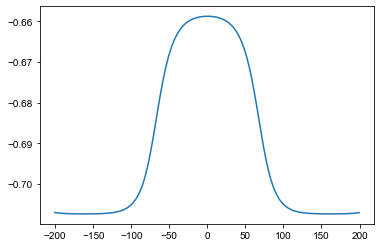

In [57]:
plt.plot(sim_JJ[0],sim_JJ[1])

In [58]:
hallbar=matplotlib.image.imread('C:/Users/jdiez/BlenderFigures/JJ_v7.png')
moire=matplotlib.image.imread('C:/Users/jdiez/BlenderFigures/JJ_moire_focus2_v2.png')

In [59]:
savename='W:/a. Members/Jaime/g. Manuscript/Figures/'

# New version 

In [60]:
#Load the extracted Ic+ and Ic-
Icposdn=np.loadtxt('W:/a. Members/Jaime/Ic_positive_SCSdn.txt')
Icnegdn=np.loadtxt('W:/a. Members/Jaime/Ic_negative_SCSdn.txt')
Icposup=np.loadtxt('W:/a. Members/Jaime/Ic_positive_SCSup.txt')

(-30.0, 30.0)

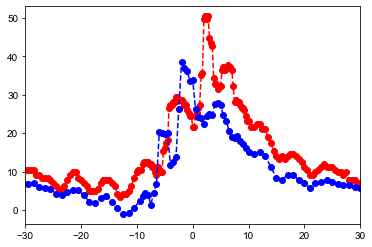

In [63]:
yup=dvdiF_obj['data0'].MagnetFieldsetpoint*1000
ydn=dvdiF_obj3['data'+str(2)].MagnetFieldsetpoint*1000
plt.plot(yup[:,0],Icposup,'ro--')
plt.plot(ydn[:,0],Icposdn,'bo--')
plt.xlim(-30,30)

In [64]:
Vns

2.21863868852459

In [65]:
ns

2.88

In [1748]:
savecount=0

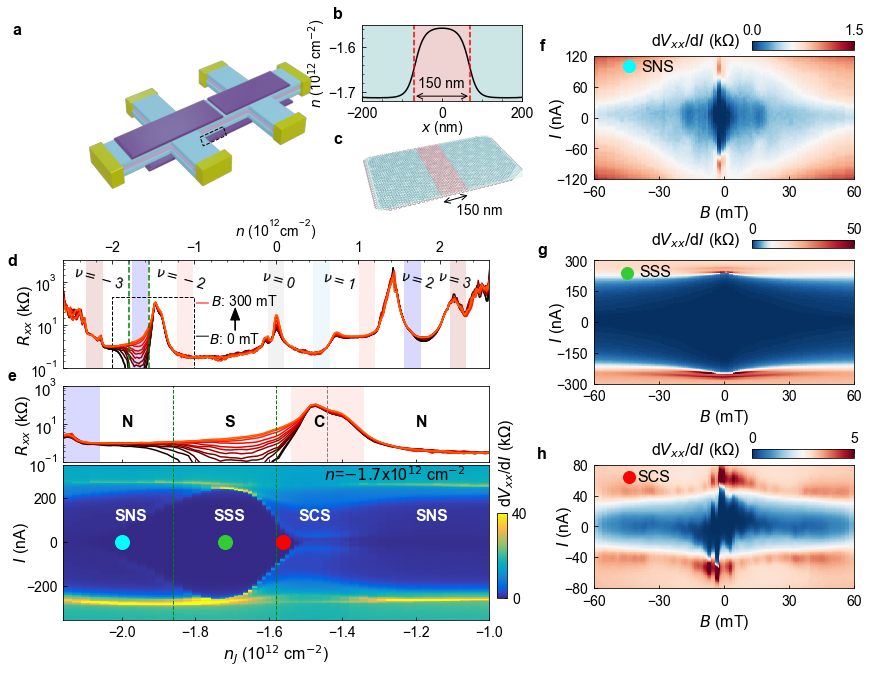

In [68]:
cm = 1/2.54  # centimeters in inches
# Size for double column nature is 183 mm and single column is 89 mm
cap=0.00185/1.602E-19/0.88
C_BG=0.00185/1.602E-19/0.88
C_TG=0.00185/1.602E-19
C_TGjj=0.00185/1.602E-19/25

CNP=0.13
CNP_main=0.06
ns=2.88

font=14
tickpad=6
if savecount==0:
    save=True
else:
    save=False 
# Fig params to save and color 

yTG=(-1.25-VBg_JJ2)/0.88

n_JJ2=((VBg_JJ2-CNP_main)*C_BG+yTG*C_TGjj)/1E16 #given in cm^-2

n_main2=((VBg_JJ2-CNP_main)*C_BG+yTG*C_TG)/1E16

linefits=True
if savecount==0:
    save=True
else:
    save=False

# terrain looks cool
#orig_cmap = matplotlib.cm.turbo
orig_cmap = parula_map
mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap,start=0,stop=1)

### START THE FIGURE

fig=plt.figure(figsize=(18*cm*2,15*cm*2))

gs=matplotlib.gridspec.GridSpec(41,24)


### FIRST THE RXX VS B

ax=fig.add_subplot(gs[18:25,:13])

count=0

for i in range(1,num_plot-1,2):  
    if i==1 or i==num_plot-4:
        ax.plot((Bc1_BG[i]-0.055)*cap/1E16,Bc1_Rxx1[i],label='$B$',color=colors[count])
    ax.plot((Bc1_BG[i]-0.055)*cap/1E16,Bc1_Rxx1[i],color=colors[count])
    count=count+1
    

ax.set_xlabel('$n$ $\mathdefault{(10^{12} cm^{-2})}$',fontsize=font)
ax.set_ylabel('$R_{xx}$ (k$\Omega$)',fontsize=font+2,labelpad=-5)

ax.set_yscale('log')

ax.set_ylim(0.1,10000)
ax.set_xlim(-2.6,2.6)

ax.xaxis.set_label_position('top')

ax.tick_params(axis='both', which='major', labelsize=font,direction='in',pad=tickpad)
ax.tick_params(axis='both', which='minor', direction='in')
ax.tick_params(axis='x',which='both', bottom=False,top=True,labelbottom=False,labeltop=True)
ax.minorticks_on()

# Make the minor ticks 

locmaj = matplotlib.ticker.LogLocator(base=10,numticks=7) 
ax.yaxis.set_major_locator(locmaj)
locmin = matplotlib.ticker.LogLocator(base=10.0,subs=(0.2,0.4,0.6,0.8),numticks=12)
ax.yaxis.set_minor_locator(locmin)
ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())

### MAKE THE LEGEND

ax.annotate('$B$: 0 mT', xy=(-0.2, 5),
            xytext=(-0.2, 5),
            arrowprops=dict(facecolor='black',width=0.5,headwidth=9, shrink=0.05),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )
ax.annotate('', xy=(-1.,3),
            xytext=(-0.8,3),
            arrowprops=dict(color='k',arrowstyle="-"
                            ,),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )
ax.annotate('', xy=(-0.5, 70),
            xytext=(-0.5, 5),
            arrowprops=dict(facecolor='black',width=0.5,headwidth=9, shrink=0.05),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )
ax.annotate('$B$: 300 mT', xy=(-0.8, 82),
            xytext=(-0.8,82),fontsize=font
            )

ax.annotate('', xy=(-1,105),
            xytext=(-0.8,105),
            arrowprops=dict(color='r',arrowstyle="-"
                            ,),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )
#plt.axvline(x=-0.67,color='grey',linestyle='dashed',linewidth=0.5)


# MAKE VERTICAL LINES AND AVSPANS FOR THE FILLING FACTORS


ax.axvline(x=-1.55,color='g',linestyle='dashed')
ax.axvline(x=-1.8,color='g',linestyle='dashed')

nu_y=500

#ax.text(2.7/cap*1E16,nu_y,r'$\nu=4$',fontsize=font,rotation=-15)
ax.text(+1.95,nu_y,r'$\nu=$3',fontsize=font,rotation=-15)
ax.text(+1.5,nu_y,r'$\nu=$2',fontsize=font,rotation=-15)
ax.text(+0.55,nu_y,r'$\nu=$1',fontsize=font,rotation=-15)
ax.text(-0.2,nu_y,r'$\nu=$0',fontsize=font,rotation=-15)
ax.text(-1.5,nu_y,r'$\nu=-$2',fontsize=font,rotation=-15)
ax.text(-2.5,nu_y,r'$\nu=-$3',fontsize=font,rotation=-15)
#ax.text(-3/cap*1E16,nu_y,r'$\nu=-4$',fontsize=font,rotation=-15)


#ax.text(0.8,0.2,'$T=35$ mK',fontsize=font)
#ax.text(0.8,0.8,'$V_{TGs}=0$ V',fontsize=font)
#ax.text(0.8,0.2,'$n_{main}=n_{JJ}=n$',fontsize=font)

ax.axvspan(-(Vns/2)+0.1, -(Vns/2)-0.1, facecolor='salmon',alpha=0.15)
ax.axvspan(-(Vns/4*3)+0.1, -(Vns/4*3)-0.1, facecolor='b',alpha=0.15)
#ax.axvspan(-(ns/2)+0.1, -(ns/2)-0.1, facecolor='b',alpha=0.1)
ax.axvspan((Vns/2)-0.1, (Vns/2)+0.1, facecolor='salmon',alpha=0.15)
ax.axvspan((Vns/4)-0.1, (Vns/4)+0.1, facecolor='skyblue',alpha=0.15)
ax.axvspan((Vns/4*3)-0.10, (Vns/4*3)+0.10, facecolor='b',alpha=0.15)
ax.axvspan(-0.1, 0.1, facecolor='silver',alpha=0.2)
ax.axvspan((Vns)-0.10, (Vns)+0.10, facecolor='firebrick',alpha=0.15)
ax.axvspan((-Vns)-0.10, (-Vns)+0.10, facecolor='firebrick',alpha=0.15)

ax.set_yticks([0.1,10,1000])

# Create a Rectangle patch
rect = matplotlib.patches.Rectangle((-2, 0.1), 1, 200, linewidth=1, edgecolor='k',
                                    ls='--',lw=1, facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

### FOCUSED FIGURE OF RXX VS N

#ax2=axs[1]
ax2=fig.add_subplot(gs[26:31,:13])

count=0

for i in range(1,num_plot-1,2):  
    #plt.plot((Bc1_BG[i]-0.055)*cap/1E16,Bc1_Rxx1[i],label='$B$'+'={0:.2f}'.format(Bc1_B[i,0]),color=colors[count])
    ax2.plot((Bc1_BG[i]-0.055)*cap/1E16,Bc1_Rxx1[i],label='$B$'+'={0:.2f}'.format(Bc1_B[i,0]),color=colors[count])
    count=count+1
    
#ax2.plot((x_35[20:-12]-0.055)*cap/1E16,y_35[20:-12],label='$B$'+'={0:.2f}'.format(Bc1_B[0,0]),color='r')
#ax2.plot((x_35-0.055)*cap/1E16,y_35R,label='$B$'+'={0:.2f}'.format(Bc1_B[0,0]),color='k')
ax2.set_ylabel('$R_{xx}$ (k$\Omega$)',fontsize=font+2,labelpad=-5)
#ax2=ax1.twinx()
ax2.set_xlim(-2.16,-1)
ax2.set_ylim(0.1,200)
ax2.set_yscale('log')
#ax2.xaxis.set_visible(False)
ax2.tick_params(axis='both', which='both', labelsize=font+1,direction='in',pad=tickpad)
ax2.tick_params(axis='x',which='both', bottom=True,top=False,labelbottom=False,labeltop=False)
ax2.tick_params(axis='y',which='both', left=True,right=False)
ax2.text(-2,8,'N',weight='bold',fontsize=font+2)
ax2.text(-1.72,8,'S',weight='bold',fontsize=font+2)
ax2.text(-1.48,8,'C',weight='bold',fontsize=font+2)
ax2.text(-1.2,8,'N',weight='bold',fontsize=font+2)
#ax2.tick_params(axis='both', which='minor', labelsize=font+1,direction='in')

ax2.axvline(x=-(ns/2),linestyle='dashed',color='grey',linewidth=1)

#ax2.axvline(x=-(ns/4),linestyle='dashed',color='grey',linewidth=1)

# The limits of the SC are really extracted from the Temperature dependance 
ax2.axvline(x=-1.58,linestyle='dashed',color='g',linewidth=1)
ax2.axvline(x=-1.86,linestyle='dashed',color='g',linewidth=1)
ax2.axvspan((-ns/2)-0.1, (-ns/2)+0.1, facecolor='salmon',alpha=0.15)
ax2.axvspan((-ns/4*3)-0.1, (-ns/4*3)+0.1, facecolor='b',alpha=0.15)

# Make the minor ticks 

locmaj2 = matplotlib.ticker.LogLocator(base=10,numticks=7) 
ax2.yaxis.set_major_locator(locmaj2)
locmin2 = matplotlib.ticker.LogLocator(base=10.0,subs=(0.2,0.4,0.6,0.8),numticks=12)
ax2.yaxis.set_minor_locator(locmin2)
ax2.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
ax2.set_yticks([0.1,10,1000])
### DVDI MAP VS NJJ

ax1=fig.add_subplot(gs[31:,:13])


im = ax1.pcolormesh(n_JJ2,DC_JJ2,Rxx1517_JJ2,cmap=mycolor,vmax=40,vmin=0,linewidth=0,rasterized=True)

ax1.set_xlabel('$n_{J}$ (10$^{12}$ cm$^{-2}$)',fontsize=font+2)
ax1.set_ylabel('$I$ (nA)',fontsize=font+2,labelpad=-5)

ax1.tick_params(axis='both', which='both', labelsize=font,direction='in',pad=tickpad)

### Add the colorbar 
cbaxes = fig.add_axes([0.55, 0.15, 0.01,0.1]) #left,bottom,width,heigth
cb = plt.colorbar(im,shrink=0.3,cax=cbaxes,orientation='vertical') 

#cb=plt.colorbar(pad=0)
cb.set_label('d$V_{xx}$/d$I$ (k$\Omega$)',fontsize=font+2,position=(-0.28,1.6), labelpad=-30,rotation=90)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in',pad=5)
cb.set_ticks([0,40])

ax1.set_xlim(-2.16,-1)

### Vertical lines for the SC
ax1.axvline(x=-1.58,linestyle='dashed',color='g',linewidth=1)
ax1.axvline(x=-1.86,linestyle='dashed',color='g',linewidth=1)
#ax.axvline(x=((-1.25-CNP_main)*C_BG)/1E16,linestyle='dashed',color='g',linewidth=1)

### Names of the different features 
ax1.text(-1.75,100,'SSS',color='w',fontsize=font+2,weight='bold')
ax1.text(-2.02,100,'SNS',color='w',fontsize=font+2,weight='bold')
ax1.text(-1.2,100,'SNS',color='w',fontsize=font+2,weight='bold')
ax1.text(-1.52,100,'SCS',color='w',fontsize=font+2,weight='bold')
ax1.text(-1.45,280,'$n$='+'${0:.1f}$'.format((-1.25-CNP_main)*cap/1E16)+'x10$^{12}$ cm$^{-2}$',fontsize=font+2,color='k')
#ax.set_ylim(-50,50)
#ax.text(-1.53,100,'SNcS',color='w',fontsize=18,weight='bold')
#ax.set_xlim(-2.82,0)

### Markers for the Fraunhofers 

ax1.plot(-2,0,'aqua',marker='o',markersize=font)
ax1.plot(-1.72,0,'limegreen',marker='o',markersize=font)
#ax.plot(-1.59,0,'magenta',marker='o',markersize=15)
ax1.plot(-1.56,0,'r',marker='o',markersize=font)

### Add the Faunhofers

### SNS

ax5=fig.add_subplot(gs[5:13,16:])

# Data
num=0
x=dvdiF_obj3['data'+str(num)].DCSource1V100nASourcevoltage*100 # in nA
y=dvdiF_obj3['data'+str(num)].MagnetFieldsetpoint*1000
yBG=-1.2-y*0.88 # in V
I718=dvdiF_obj3['data'+str(num)].Rxx4X # in nA
z1517=dvdiF_obj3['data'+str(num)].Rxx1_Ampx10X/I718/1000/10 # in kOhm
z51=dvdiF_obj3['data'+str(num)].Rxx2_Ampx10X/I718/1000/10 # in kOhm

    
orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.4,orig_cmap)

im5 = plt.pcolormesh(y,x,z1517,cmap=mycolor,vmin=0,vmax=1.5,linewidth=0,rasterized=True)

ax5.set_ylabel('$I$ (nA)',fontsize=font+2,labelpad=-10)
ax5.set_xlabel('$B$ (mT)',fontsize=font+2)
#ax.yaxis.set_label_coords(-0.1,0.5)
#ax.set_xticks(ticks)
#ax.set_yticks(ticks)

ax5.tick_params(axis='both', which='major', labelsize=font,direction='in',pad=tickpad)
ax5.set_xticks([-60,-30,0,30,60])
ax5.set_yticks([-120,-60,0,120,60])
### Add the colorbar 
cbaxes = fig.add_axes([0.8, 0.795, 0.1,0.01]) #left,bottom,width,heigth
cb = plt.colorbar(im5,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('d$V_{xx}/$d$I$ (k$\Omega$)',fontsize=font+2,position=(-0.55,1), labelpad=-18,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')
cb.set_ticks([0,1.5])
ax5.set_ylim(-120,120)
ax5.set_xlim(-60,60)
#ax.set_title('$SNcS$ $V_{BG}:-1.12$ V, $V_{TGs}:-147$ mV',fontsize=font,position=(0.45,0.92),color='k',bbox=dict(facecolor='w',edgecolor='k'))

ax5.text(-38,90,'SNS',fontsize=font+2,color='k')
ax5.plot(-44,100,'aqua',marker='o',markersize=12)


### SSS

ax4=fig.add_subplot(gs[18:26,16:])

# Data
num=1

x=dvdiF_obj3['data'+str(num)].DCSource1V100nASourcevoltage*100 # in nA
y=dvdiF_obj3['data'+str(num)].MagnetFieldsetpoint*1000
yBG=-1.2-y*0.88 # in V
I718=dvdiF_obj3['data'+str(num)].Rxx4X # in nA
z1517=dvdiF_obj3['data'+str(num)].Rxx1_Ampx10X/I718/1000/10 # in kOhm
z51=dvdiF_obj3['data'+str(num)].Rxx2_Ampx10X/I718/1000/10 # in kOhm

orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.2,orig_cmap)


im4 = plt.pcolormesh(y,x,z1517,cmap=mycolor,vmin=0,vmax=50,linewidth=0,rasterized=True)

ax4.set_ylabel('$I$ (nA)',fontsize=font+2,labelpad=-10)
ax4.set_xlabel('$B$ (mT)',fontsize=font+2)


ax4.tick_params(axis='both', which='major', labelsize=font,direction='in',pad=tickpad)
ax4.set_yticks([-300,-150,0,150,300])
ax4.set_xticks([-60,-30,0,30,60])
ax4.set_ylim(-300,300)
ax4.set_xlim(-60,60)

### Add the colorbar 
cbaxes = fig.add_axes([0.8, 0.5615, 0.1,0.01]) #left,bottom,width,heigth
cb = plt.colorbar(im4,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('d$V_{xx}/$d$I$ (k$\Omega$)',fontsize=font+2,position=(-0.55,1), labelpad=-18,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')
cb.set_ticks([0,50])
#ax.set_xlim(-200,200)

#ax.set_title('$SNcS$ $V_{BG}:-1.12$ V, $V_{TGs}:-147$ mV',fontsize=font,position=(0.45,0.92),color='k',bbox=dict(facecolor='w',edgecolor='k'))
ax4.text(-39,220,'SSS',fontsize=font+2,color='k')
ax4.plot(-45,237,'limegreen',marker='o',markersize=12)


### SCS

# Data
num=2

x=dvdiF_obj3['data'+str(num)].DCSource1V100nASourcevoltage*100 # in nA
y=dvdiF_obj3['data'+str(num)].MagnetFieldsetpoint*1000
yBG=-1.2-y*0.88 # in V
I718=dvdiF_obj3['data'+str(num)].Rxx4X # in nA
z1517=dvdiF_obj3['data'+str(num)].Rxx1_Ampx10X/I718/1000/10 # in kOhm
z51=dvdiF_obj3['data'+str(num)].Rxx2_Ampx10X/I718/1000/10 # in kOhm

  
orig_cmap = matplotlib.cm.RdBu_r

mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap)

ax6=fig.add_subplot(gs[31:39,16:])

im6 = plt.pcolormesh(y,x,z1517,cmap=mycolor,vmin=0,vmax=5,linewidth=0,rasterized=True)

ax6.set_ylabel('$I$ (nA)',fontsize=font+2,labelpad=-10)
ax6.set_xlabel('$B$ (mT)',fontsize=font+2)


ax6.tick_params(axis='both', which='major', labelsize=font,direction='in',pad=tickpad)
ax6.set_xticks([-60,-30,0,30,60])
ax6.set_yticks([-80,-40,0,40,80])

### Add the colorbar 
cbaxes = fig.add_axes([0.8, 0.315, 0.1,0.01]) #left,bottom,width,heigth
cb = plt.colorbar(im6,shrink=0.3,cax=cbaxes,orientation='horizontal') 

#cb=plt.colorbar(pad=0)
cb.set_label('d$V_{xx}/$d$I$ (k$\Omega$)',fontsize=font+2,position=(-0.55,1), labelpad=-18,rotation=0)
cbaxes.xaxis.tick_top()
cb.ax.tick_params(labelsize=font,direction='in')
cb.set_ticks([0,5])

ax6.set_xlim(-60,60)
ax6.set_ylim(-80,80)

#ax.set_title('$SNcS$ $V_{BG}:-1.12$ V, $V_{TGs}:-147$ mV',fontsize=font,position=(0.45,0.92),color='k',bbox=dict(facecolor='w',edgecolor='k'))

ax6.text(-40,58,'SCS',fontsize=font+2,color='k')
ax6.plot(-44,64,'r',marker='o',markersize=12)

### ADD THE SIMULATION 

ax7=fig.add_subplot(gs[3:8,9:14])

ax7.plot(sim_JJ[0],sim_JJ[1]/0.3125+0.55,'k')
ax7.axvline(x=-70,color='r',linestyle='dashed')
ax7.axvline(x=70,color='r',linestyle='dashed')
#ax.plot(x[0],x[0]*0,linestyle='dashed',color='gray',linewidth=2)
ax7.set_xlabel('$x$ (nm)',fontsize=font,labelpad=-2)
ax7.set_ylabel('$n$ (10$^{12}$ cm$^{-2}$)',fontsize=font,labelpad=0)

ax7.tick_params(axis='y',labelleft=True,labelright=False)


ax7.tick_params(axis='both',which='major',labelsize=font,direction='in',pad=tickpad)
ax7.tick_params(axis='both',which='minor',direction='in')
ax7.minorticks_on()

ax7.set_xlim(-200,200)
ax7.set_ylim(-1.72,-1.55)

ax7.annotate('', xy=(-70,-1.71),
            xytext=(70,-1.71),
            arrowprops=dict(color='k',arrowstyle='<->'),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )
ax7.text(-60,-1.69,'150 nm',fontsize=font)
ax7.axvspan(-200,-70,facecolor='teal',alpha=0.2)
ax7.axvspan(70,200,facecolor='teal',alpha=0.2)
ax7.axvspan(-70,70,facecolor='firebrick',alpha=0.2)

### ADD THE DIAGRAMS

ax8=fig.add_subplot(gs[4:15,:8])
ax8.imshow(hallbar,aspect='auto')
ax8.axis('off')
rect2 = matplotlib.patches.Rectangle((660,410), 120, 40, linewidth=1, edgecolor='k',
                                    ls='--',lw=1, facecolor='none',angle=-22)
circle1 = matplotlib.patches.Circle((920,650), 70, linewidth=1, edgecolor='k',
                                    ls='-',lw=1, facecolor='none')
circle2 = matplotlib.patches.Circle((80,750), 70, linewidth=1, edgecolor='k',
                                    ls='-',lw=1, facecolor='none')
ax8.add_patch(rect2)
'''
ax8.add_patch(circle1)
ax8.add_patch(circle2)
#ax8.text(850,700,'$V_{xx}$',fontsize=font+2)
ax8.annotate('$V_{xx}$',xy=(920,665),ha='center',fontsize=font+2)
ax8.annotate('$V_{bias}$',xy=(150,800),fontsize=font+2)
ax8.annotate('', xy=(80,700),
            xytext=(80,550),
            arrowprops=dict(color='k',arrowstyle="-"
                            ),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )
ax8.annotate('', xy=(70,560),
            xytext=(150,560),
            arrowprops=dict(color='k',arrowstyle="-"
                            ),
            horizontalalignment='right', verticalalignment='top',fontsize=font
            )
'''
       
### MOIRE DIAGRAM
ax9=fig.add_subplot(gs[10:15,9:14])

plt.imshow(moire,aspect='auto')
ax9.axis('off')
'''
ax9.text(720,500,'$n_{J}$',fontsize=font+2)
ax9.text(950,400,'$n$',fontsize=font+2)
ax9.text(250,600,'$n$',fontsize=font+2)
'''
ax9.annotate('', xy=(850,850),
            xytext=(1150,750),
            arrowprops=dict(arrowstyle='<->',color='k'),
            horizontalalignment='right', verticalalignment='top',fontsize=font,
            )
ax9.text(1000,1000,'150 nm',fontsize=font)

### Set the labels 

ax8.set_title('a',fontsize=font+2,weight='bold',position=(-0.18,1))
ax7.set_title('b',fontsize=font+2,weight='bold',position=(-0.15,1))
ax9.set_title('c',fontsize=font+2,weight='bold',position=(-0.15,0.8))
ax.set_title('d',fontsize=font+2,weight='bold',position=(-0.12,0.9))
#ax1.set_title('e',fontsize=font,weight='bold',position=(-0.15,1))
ax2.set_title('e',fontsize=font+2,weight='bold',position=(-0.12,1))
ax5.set_title('f',fontsize=font+2,weight='bold',position=(-0.2,1))
ax4.set_title('g',fontsize=font+2,weight='bold',position=(-0.2,1))
ax6.set_title('h',fontsize=font+2,weight='bold',position=(-0.2,1))



if save:
    plt.savefig(savename+'Fig1_full_v1'+time.strftime("%H%M%d%m%y")+'.pdf',dpi=600,bbox_inches='tight') 
    savecount=savecount+1
    
plt.show()

In [1762]:
savecount=0